# Distributed DBSCAN Architecture & Code Explanation

This notebook explains the **distributed DBSCAN algorithm** step-by-step with visualizations that map directly to the Java code architecture.

**Main Java File:** `ExecuteDBSCAN.java`

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches
import networkx as nx
from collections import defaultdict

np.random.seed(42)

# Configure plotting
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


## Tutorial: Complete Union-Find Visualization

This single comprehensive visualization demonstrates:
- **Union-Find structure** as a directed graph (top-left)
- **Step-by-step evolution** through union operations (top-right, bottom-left, bottom-right)
- **Key-to-Root mapping** visualization (middle section)
- **Root-to-Global ID mapping** (right section)

All in one figure!

Simple Dataset:
  Elements: A, B, C, D
  Union operations:
    Step 1: union(A, B)
    Step 2: union(B, C)
    Step 3: D remains isolated



/var/folders/0c/bg7lszj94cz0b84y_45p31x80000gn/T/ipykernel_2460/1346069869.py:265: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.96])


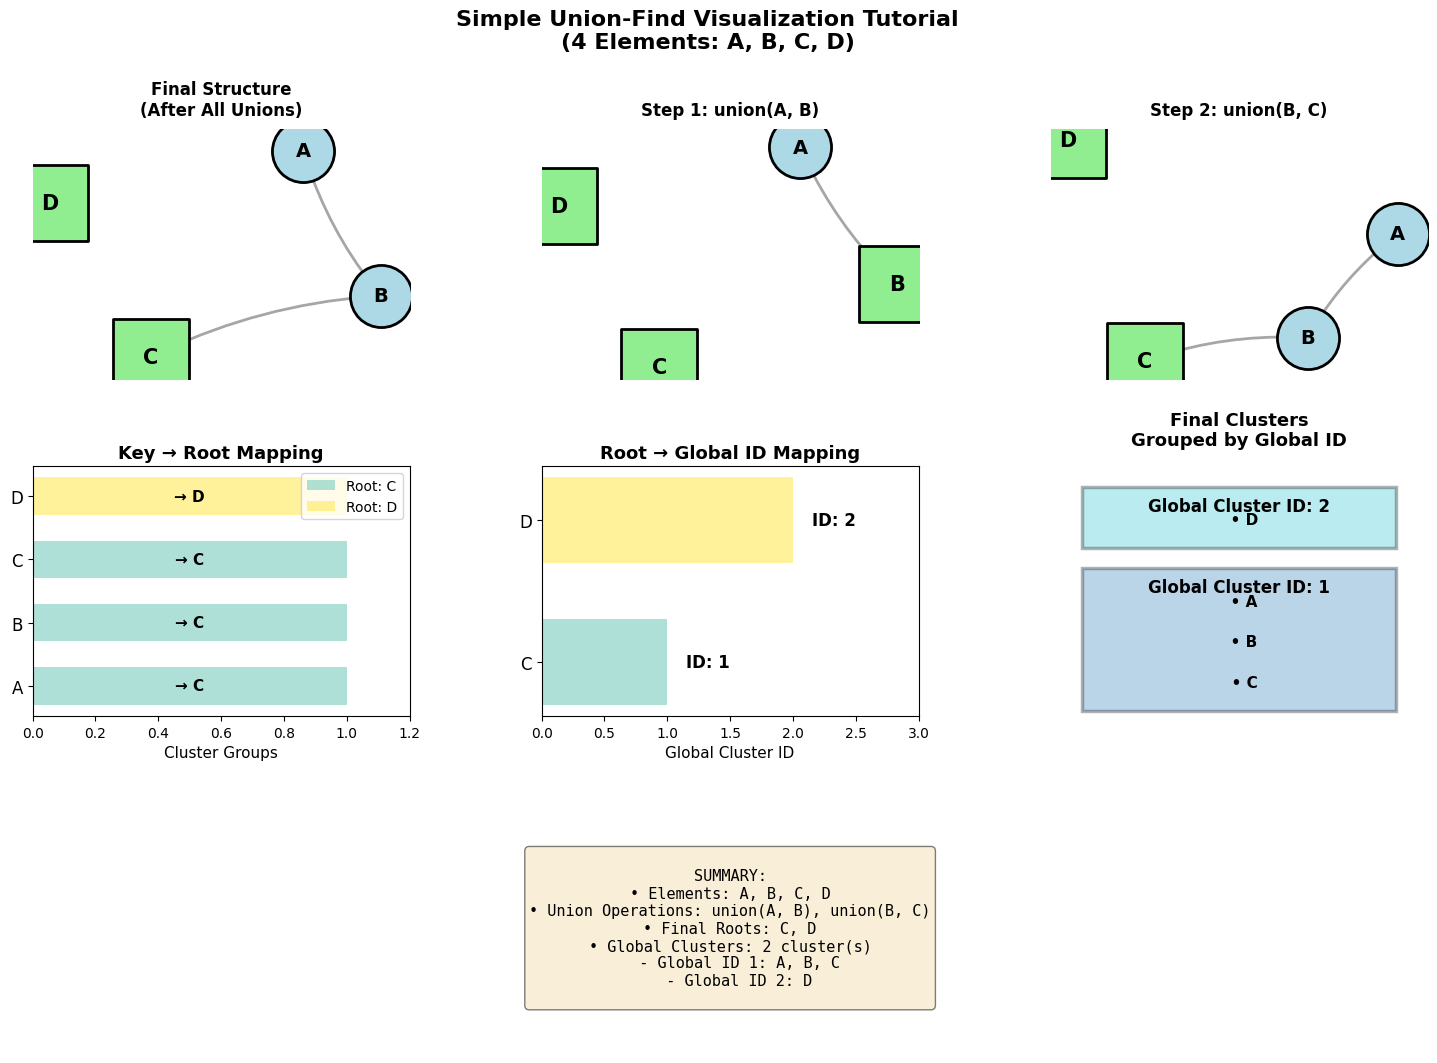

SIMPLE VISUALIZATION CREATED!

Dataset: 4 elements
Union Operations: 2

Final Structure:
  Root nodes: ['C', 'D']
  Total nodes: 4

Key-to-Root Mapping:
  A → C
  B → C
  C → C
  D → D

Root-to-Global Mapping:
  C → Global ID 1
  D → Global ID 2

Final Cluster Groups:
  Global ID 1: A, B, C
  Global ID 2: D


In [ ]:
# ============================================
# SIMPLE TUTORIAL: Union-Find Visualization with Simple Dataset
# ============================================
"""
Simple example with only 4 elements (A, B, C, D) to make it easy to understand.

This visualization shows:
1. Final Union-Find structure (top-left)
2. Step-by-step evolution (top-right, bottom-left)
3. Key-to-Root mapping (middle-left)
4. Root-to-Global ID mapping (middle-right)
5. Final cluster grouping (bottom section)
"""

import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# Simple Union-Find implementation
class UnionFindVisualizer:
    def __init__(self):
        self.parent = {}
    
    def find(self, x):
        if x not in self.parent:
            self.parent[x] = x
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, a, b):
        pa = self.find(a)
        pb = self.find(b)
        if pa != pb:
            self.parent[pa] = pb
        return pa != pb
    
    def get_key_to_root(self):
        key_to_root = {}
        for k in self.parent.keys():
            key_to_root[k] = self.find(k)
        return key_to_root
    
    def get_root_to_global(self, key_to_root):
        roots = set(key_to_root.values())
        root_to_global = {}
        global_id = 1
        for root in sorted(roots):
            root_to_global[root] = global_id
            global_id += 1
        return root_to_global

# SIMPLE DATASET: Only 4 elements with 3 union operations
# Easy to follow: A connects to B, then B connects to C, creating one cluster
# D remains separate
unions = [
    ("A", "B"),    # Step 1: Merge A and B
    ("B", "C"),    # Step 2: Merge B and C (A, B, C now together)
    ("D", "D")     # Step 3: D stays alone (no actual union needed)
]

# All elements in the small dataset
all_elements = ["A", "B", "C", "D"]

# Helper to initialize a Union-Find that already knows all elements
# (so D will appear even before any unions)
def init_uf_with_all_elements():
    uf = UnionFindVisualizer()
    for e in all_elements:
        uf.parent[e] = e
    return uf

print("Simple Dataset:")
print("  Elements: A, B, C, D")
print("  Union operations:")
for i, (a, b) in enumerate(unions, 1):
    if a != b:
        print(f"    Step {i}: union({a}, {b})")
    else:
        print(f"    Step {i}: {a} remains isolated")
print()

# Helper function to visualize a Union-Find state
def draw_uf_state(ax, uf, title, pos=None):
    """Draw Union-Find structure on given axis"""
    G = nx.DiGraph()
    for node in uf.parent.keys():
        G.add_node(node)
    
    for child, parent in uf.parent.items():
        if child != parent:
            G.add_edge(child, parent)
    
    roots = [n for n in G.nodes() if uf.parent[n] == n]
    non_roots = [n for n in G.nodes() if n not in roots]
    
    # Use fixed positions for simple layout
    if pos is None:
        pos = nx.spring_layout(G, k=3, iterations=50, seed=42)
    else:
        new_nodes = [n for n in G.nodes() if n not in pos]
        if new_nodes:
            for node in new_nodes:
                pos[node] = np.random.rand(2) * 2 - 1
        pos = nx.spring_layout(G, pos=pos, k=3, iterations=50, seed=42)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray',
                          arrows=True, arrowsize=20, arrowstyle='->',
                          connectionstyle='arc3,rad=0.1', alpha=0.7, width=2)
    
    # Draw non-root nodes (larger for visibility)
    if non_roots:
        nx.draw_networkx_nodes(G, pos, nodelist=non_roots,
                              node_color='lightblue', node_size=2000,
                              ax=ax, node_shape='o', edgecolors='black', linewidths=2)
        nx.draw_networkx_labels(G, pos, {n: n for n in non_roots},
                              font_size=14, ax=ax, font_weight='bold')
    
    # Draw root nodes (larger for visibility)
    if roots:
        nx.draw_networkx_nodes(G, pos, nodelist=roots,
                              node_color='lightgreen', node_size=3000,
                              ax=ax, node_shape='s', edgecolors='black', linewidths=2)
        nx.draw_networkx_labels(G, pos, {n: n for n in roots},
                              font_size=15, font_weight='bold', ax=ax)
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
    ax.axis('off')
    return pos

# Create comprehensive figure (smaller for simple dataset)
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# ========== TOP ROW: Final Structure + Step-by-Step Evolution ==========
# Top-left: Final Union-Find structure (A, B, C in one set; D alone)
ax1 = fig.add_subplot(gs[0, 0])
uf_final = init_uf_with_all_elements()
for a, b in unions:
    if a != b:  # Skip self-unions
        uf_final.union(a, b)
pos_final = draw_uf_state(ax1, uf_final, "Final Structure\n(After All Unions)", None)

# Top-middle: Step 1 (A ↔ B, C and D still alone)
ax2 = fig.add_subplot(gs[0, 1])
uf1 = init_uf_with_all_elements()
uf1.union(unions[0][0], unions[0][1])
pos1 = draw_uf_state(ax2, uf1, f"Step 1: union({unions[0][0]}, {unions[0][1]})", None)

# Top-right: Step 2 (A, B, C together; D still alone)
ax3 = fig.add_subplot(gs[0, 2])
uf2 = init_uf_with_all_elements()
uf2.union(unions[0][0], unions[0][1])
uf2.union(unions[1][0], unions[1][1])
pos2 = draw_uf_state(ax3, uf2, f"Step 2: union({unions[1][0]}, {unions[1][1]})", pos1)

# ========== MIDDLE ROW: Mappings ==========
# Middle-left: Key to Root mapping
ax5 = fig.add_subplot(gs[1, 0])
key_to_root = uf_final.get_key_to_root()
keys = sorted(key_to_root.keys())
roots_list = [key_to_root[k] for k in keys]

unique_roots = sorted(set(roots_list))
root_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_roots)))
root_color_map = {root: root_colors[i] for i, root in enumerate(unique_roots)}

y_pos = np.arange(len(keys))
colors = [root_color_map[key_to_root[k]] for k in keys]

bars5 = ax5.barh(y_pos, [1]*len(keys), color=colors, alpha=0.7, height=0.6)
ax5.set_yticks(y_pos)
ax5.set_yticklabels(keys, fontsize=12)
ax5.set_xlabel('Cluster Groups', fontsize=11)
ax5.set_title('Key → Root Mapping', fontsize=13, fontweight='bold')
ax5.set_xlim(0, 1.2)

for i, (key, root) in enumerate(zip(keys, roots_list)):
    ax5.text(0.5, i, f'→ {root}', va='center', ha='center',
            fontsize=11, fontweight='bold')

legend_elements = [plt.Rectangle((0,0),1,1, facecolor=root_color_map[r],
                                 alpha=0.7, label=f'Root: {r}')
                  for r in unique_roots]
ax5.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Middle-right: Root to Global ID mapping
ax6 = fig.add_subplot(gs[1, 1])
root_to_global = uf_final.get_root_to_global(key_to_root)
roots_sorted = sorted(root_to_global.keys())
global_ids = [root_to_global[r] for r in roots_sorted]

colors_global = [root_color_map[r] for r in roots_sorted]
y_pos2 = np.arange(len(roots_sorted))

bars = ax6.barh(y_pos2, global_ids, color=colors_global, alpha=0.7, height=0.6)
ax6.set_yticks(y_pos2)
ax6.set_yticklabels(roots_sorted, fontsize=12)
ax6.set_xlabel('Global Cluster ID', fontsize=11)
ax6.set_title('Root → Global ID Mapping', fontsize=13, fontweight='bold')
ax6.set_xlim(0, max(global_ids) + 1)

for i, (bar, gid) in enumerate(zip(bars, global_ids)):
    ax6.text(bar.get_width() + 0.15, bar.get_y() + bar.get_height()/2,
            f'ID: {gid}', va='center', fontsize=12, fontweight='bold')

# ========== BOTTOM SECTION: Cluster Grouping ==========
ax7 = fig.add_subplot(gs[1, 2])
groups = defaultdict(list)
for key in key_to_root.keys():
    root = key_to_root[key]
    global_id = root_to_global[root]
    groups[global_id].append(key)

y_offset = 0
colors_group = plt.cm.tab10(np.linspace(0, 1, len(groups)))

for idx, (global_id, keys_group) in enumerate(sorted(groups.items())):
    num_keys = len(keys_group)
    box_height = num_keys * 0.8 + 0.4
    
    box = plt.Rectangle((0, y_offset), 1, box_height,
                       facecolor=colors_group[idx], alpha=0.3,
                       edgecolor='black', linewidth=2.5)
    ax7.add_patch(box)
    
    ax7.text(0.5, y_offset + box_height - 0.2,
            f'Global Cluster ID: {global_id}',
            ha='center', va='top', fontsize=12, fontweight='bold')
    
    for i, key in enumerate(sorted(keys_group)):
        ax7.text(0.5, y_offset + box_height - 0.5 - i*0.8,
                f'  • {key}', ha='center', va='top', fontsize=11, fontweight='bold')
    
    y_offset += box_height + 0.4

ax7.set_xlim(-0.1, 1.1)
ax7.set_ylim(-0.1, y_offset)
ax7.set_title('Final Clusters\nGrouped by Global ID', fontsize=13, fontweight='bold', pad=15)
ax7.axis('off')

# ========== BOTTOM ROW: Summary Text ==========
ax8 = fig.add_subplot(gs[2, :])
ax8.axis('off')
summary_text = f"""
SUMMARY:
• Elements: {', '.join(sorted(uf_final.parent.keys()))}
• Union Operations: union({unions[0][0]}, {unions[0][1]}), union({unions[1][0]}, {unions[1][1]})
• Final Roots: {', '.join(sorted([n for n in uf_final.parent.keys() if uf_final.parent[n] == n]))}
• Global Clusters: {len(groups)} cluster(s)
"""
for gid, keys_group in sorted(groups.items()):
    summary_text += f"  - Global ID {gid}: {', '.join(sorted(keys_group))}\n"

ax8.text(0.5, 0.5, summary_text, ha='center', va='center',
        fontsize=11, family='monospace', bbox=dict(boxstyle='round', 
        facecolor='wheat', alpha=0.5))

# ========== MAIN TITLE ==========
fig.suptitle('Union-Find\n(4 Elements: A, B, C, D)', 
             fontsize=16, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("="*70)
print("SIMPLE VISUALIZATION CREATED!")
print("="*70)
print(f"\nDataset: {len(uf_final.parent)} elements")
print(f"Union Operations: {len([u for u in unions if u[0] != u[1]])}")
print(f"\nFinal Structure:")
print(f"  Root nodes: {[n for n in uf_final.parent.keys() if uf_final.parent[n] == n]}")
print(f"  Total nodes: {len(uf_final.parent)}")
print(f"\nKey-to-Root Mapping:")
for k, root in sorted(key_to_root.items()):
    print(f"  {k} → {root}")
print(f"\nRoot-to-Global Mapping:")
for root, gid in sorted(root_to_global.items()):
    print(f"  {root} → Global ID {gid}")
print(f"\nFinal Cluster Groups:")
for gid, keys_group in sorted(groups.items()):
    print(f"  Global ID {gid}: {', '.join(sorted(keys_group))}")
print("="*70)

### Step 2: Visualizing Union-Find Structure

The Union-Find data structure uses a **parent map** where each element points to its parent. We visualize this as a directed graph.

**Key Steps:**
1. Extract parent relationships from your data structure
2. Create a graph with nodes and edges
3. Identify root nodes (nodes that point to themselves)
4. Use different colors/shapes to distinguish roots from regular nodes
5. Draw with appropriate styling

Root nodes: ['13_2', '21_1']
Non-root nodes: ['12_1', '14_1', '20_1']


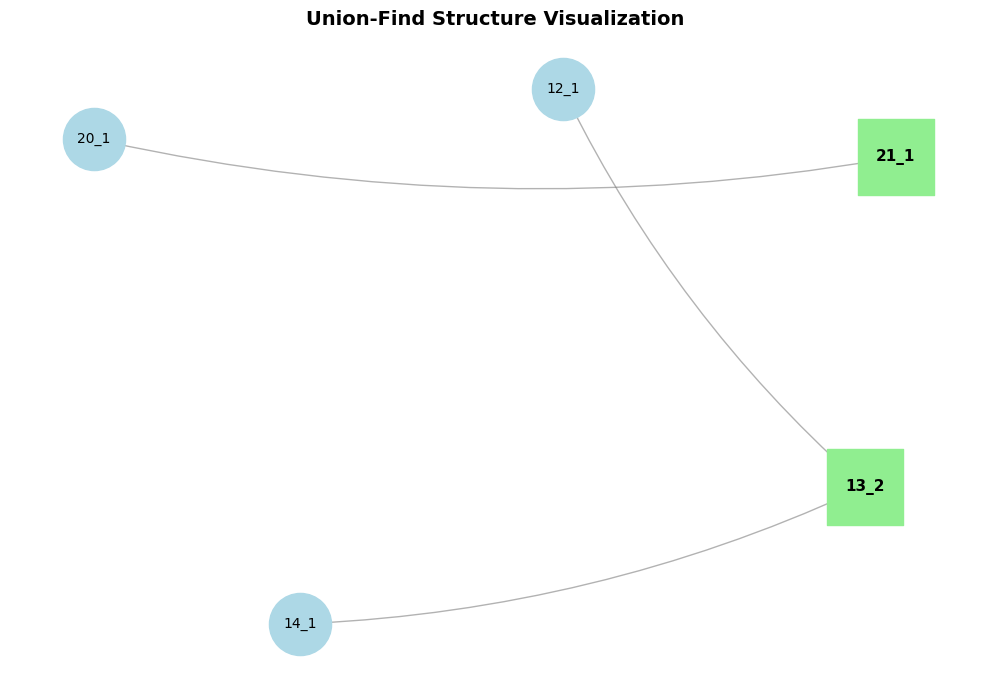


✓ Visualization created!
Blue circles = regular nodes, Green squares = root nodes


In [7]:
# ============================================
# TUTORIAL: Visualizing Union-Find Step by Step
# ============================================

# Example: Simple Union-Find parent map
parent_map = {
    "12_1": "13_2",  # 12_1 points to 13_2
    "13_2": "13_2",  # 13_2 is a root (points to itself)
    "14_1": "13_2",  # 14_1 points to 13_2
    "20_1": "21_1",  # 20_1 points to 21_1
    "21_1": "21_1"   # 21_1 is a root
}

# Step 1: Create graph and add nodes
G = nx.DiGraph()
for node in parent_map.keys():
    G.add_node(node)

# Step 2: Add edges (only non-self loops)
for child, parent in parent_map.items():
    if child != parent:  # Skip self-loops (roots)
        G.add_edge(child, parent)

# Step 3: Identify roots
roots = [node for node in parent_map.keys() if parent_map[node] == node]
non_roots = [node for node in parent_map.keys() if parent_map[node] != node]

print(f"Root nodes: {roots}")
print(f"Non-root nodes: {non_roots}")

# Step 4: Create layout
pos = nx.spring_layout(G, k=2, iterations=50, seed=42)

# Step 5: Draw the visualization
fig, ax = plt.subplots(figsize=(10, 7))

# Draw edges first (so they appear behind nodes)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', 
                      arrows=True, arrowsize=20, arrowstyle='->',
                      connectionstyle='arc3,rad=0.1', alpha=0.6)

# Draw non-root nodes (blue circles)
if non_roots:
    nx.draw_networkx_nodes(G, pos, nodelist=non_roots,
                          node_color='lightblue', node_size=2000,
                          ax=ax, node_shape='o')
    nx.draw_networkx_labels(G, pos, {n: n for n in non_roots},
                            font_size=10, ax=ax)

# Draw root nodes (green squares) - draw last so they appear on top
if roots:
    nx.draw_networkx_nodes(G, pos, nodelist=roots,
                          node_color='lightgreen', node_size=3000,
                          ax=ax, node_shape='s')
    nx.draw_networkx_labels(G, pos, {n: n for n in roots},
                            font_size=11, font_weight='bold', ax=ax)

ax.set_title("Union-Find Structure Visualization", fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.show()

print("\n✓ Visualization created!")
print("Blue circles = regular nodes, Green squares = root nodes")

### Step 3: Creating Step-by-Step Evolution Visualizations

To show how a data structure evolves, we create **multiple subplots** - one for each step.

**Technique:**
- Use `plt.subplots()` to create a grid of plots
- For each step, update your data structure
- Draw the current state in the corresponding subplot
- Use consistent layout across all steps for comparison

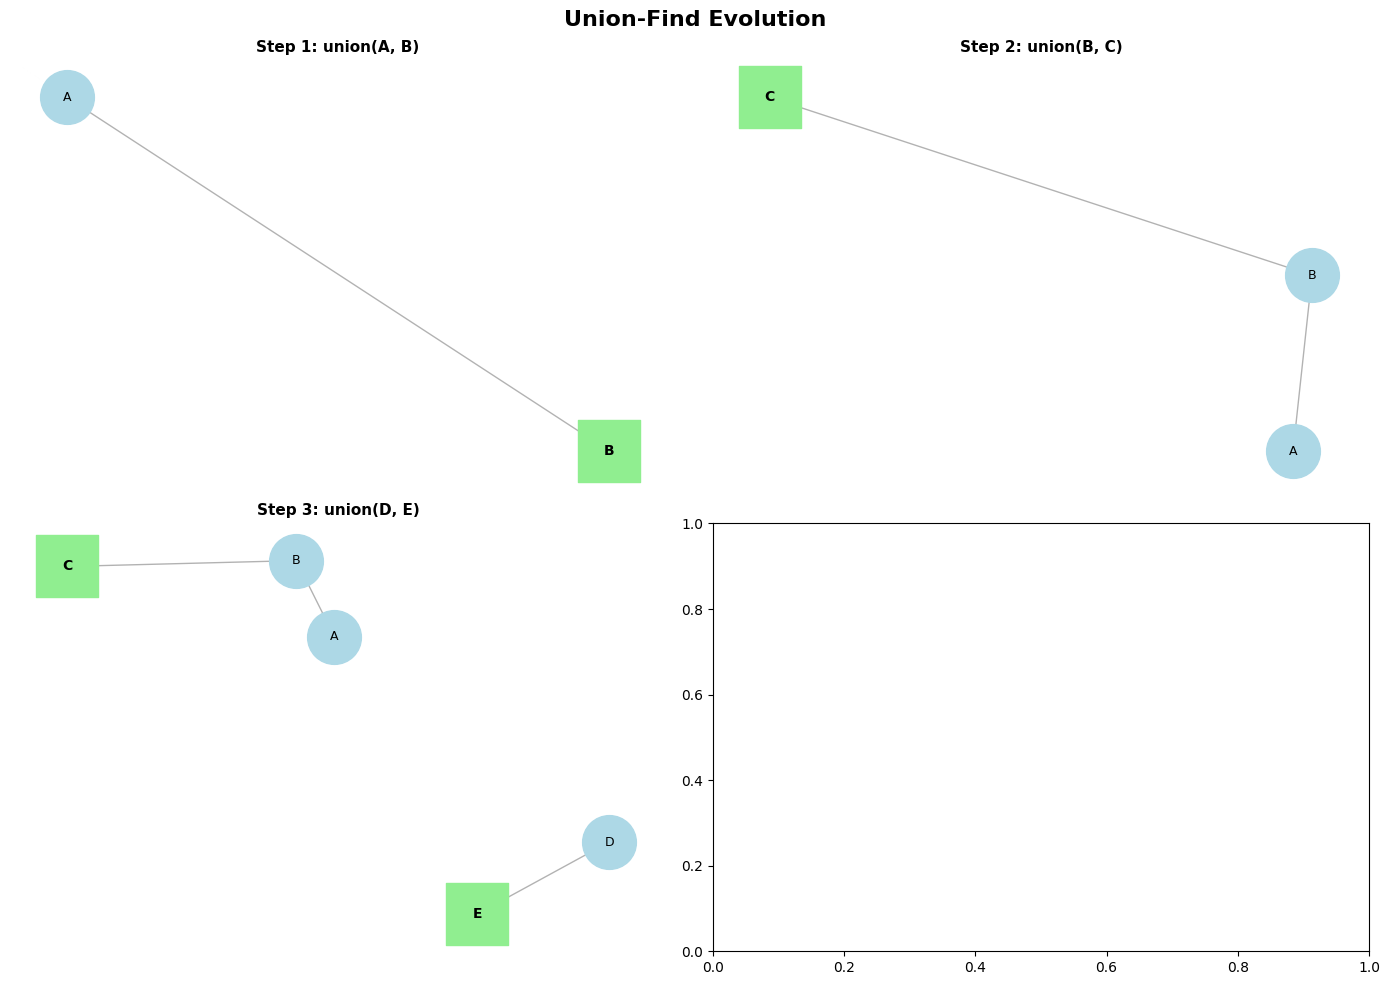

✓ Step-by-step visualization created!
Each subplot shows the state after one union operation


In [8]:
# ============================================
# TUTORIAL: Step-by-Step Evolution Visualization
# ============================================

# Example: Show Union-Find evolution through union operations
class SimpleUF:
    def __init__(self):
        self.parent = {}
    
    def find(self, x):
        if x not in self.parent:
            self.parent[x] = x
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, a, b):
        pa = self.find(a)
        pb = self.find(b)
        if pa != pb:
            self.parent[pa] = pb
        return pa != pb

# Union operations to visualize
operations = [
    ("A", "B"),
    ("B", "C"),
    ("D", "E")
]

# Create subplots: 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # Convert to 1D array for easier indexing

uf = SimpleUF()

# Process each operation and visualize
for idx, (a, b) in enumerate(operations):
    # Perform union
    uf.union(a, b)
    
    # Create graph for current state
    G = nx.DiGraph()
    for node in uf.parent.keys():
        G.add_node(node)
    
    for child, parent in uf.parent.items():
        if child != parent:
            G.add_edge(child, parent)
    
    roots = [n for n in G.nodes() if uf.parent[n] == n]
    non_roots = [n for n in G.nodes() if n not in roots]
    
    # Use consistent layout (calculate once, reuse)
    if idx == 0:
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    else:
        # Add new nodes to existing layout
        new_nodes = [n for n in G.nodes() if n not in pos]
        if new_nodes:
            for node in new_nodes:
                pos[node] = np.random.rand(2) * 2 - 1
        pos = nx.spring_layout(G, pos=pos, k=2, iterations=50, seed=42)
    
    ax = axes[idx]
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray',
                          arrows=True, arrowsize=15, alpha=0.6)
    
    # Draw nodes
    if non_roots:
        nx.draw_networkx_nodes(G, pos, nodelist=non_roots,
                              node_color='lightblue', node_size=1500, ax=ax)
        nx.draw_networkx_labels(G, pos, {n: n for n in non_roots},
                                font_size=9, ax=ax)
    
    if roots:
        nx.draw_networkx_nodes(G, pos, nodelist=roots,
                              node_color='lightgreen', node_size=2000,
                              ax=ax, node_shape='s')
        nx.draw_networkx_labels(G, pos, {n: n for n in roots},
                                font_size=10, font_weight='bold', ax=ax)
    
    ax.set_title(f"Step {idx+1}: union({a}, {b})", fontsize=11, fontweight='bold')
    ax.axis('off')

plt.suptitle("Union-Find Evolution", fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("✓ Step-by-step visualization created!")
print("Each subplot shows the state after one union operation")

### Step 4: Visualizing Mappings and Relationships

Sometimes you need to visualize **mappings** (key → value relationships) rather than graph structures. Use bar charts or grouped visualizations.

**Common patterns:**
- **Horizontal bar charts**: For key-to-value mappings
- **Grouped boxes**: For hierarchical relationships
- **Color coding**: Use colors to group related items

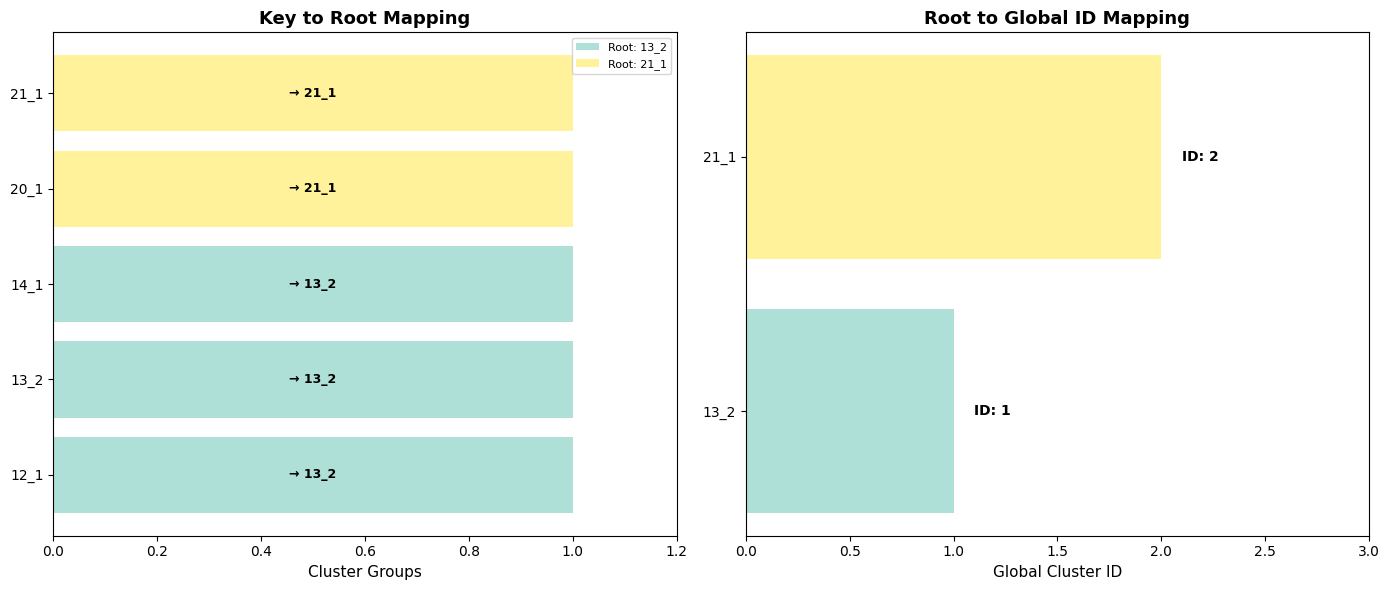

✓ Mapping visualizations created!
Left: Shows which keys map to which roots
Right: Shows which roots map to which global IDs


In [9]:
# ============================================
# TUTORIAL: Visualizing Mappings
# ============================================

# Example: Key-to-Root and Root-to-Global mappings
key_to_root = {
    "12_1": "13_2",
    "13_2": "13_2",
    "14_1": "13_2",
    "20_1": "21_1",
    "21_1": "21_1"
}

root_to_global = {
    "13_2": 1,
    "21_1": 2
}

# Create figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ===== Plot 1: Key to Root Mapping =====
keys = sorted(key_to_root.keys())
roots_list = [key_to_root[k] for k in keys]

# Color mapping: same root = same color
unique_roots = sorted(set(roots_list))
root_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_roots)))
root_color_map = {root: root_colors[i] for i, root in enumerate(unique_roots)}

y_pos = np.arange(len(keys))
colors = [root_color_map[key_to_root[k]] for k in keys]

# Create horizontal bars
bars1 = ax1.barh(y_pos, [1]*len(keys), color=colors, alpha=0.7)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(keys)
ax1.set_xlabel('Cluster Groups', fontsize=11)
ax1.set_title('Key to Root Mapping', fontsize=13, fontweight='bold')
ax1.set_xlim(0, 1.2)

# Add root labels on bars
for i, (key, root) in enumerate(zip(keys, roots_list)):
    ax1.text(0.5, i, f'→ {root}', va='center', ha='center',
            fontsize=9, fontweight='bold')

# Add legend
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=root_color_map[r],
                                 alpha=0.7, label=f'Root: {r}')
                  for r in unique_roots]
ax1.legend(handles=legend_elements, loc='upper right', fontsize=8)

# ===== Plot 2: Root to Global ID Mapping =====
roots_sorted = sorted(root_to_global.keys())
global_ids = [root_to_global[r] for r in roots_sorted]

colors_global = [root_color_map[r] for r in roots_sorted]
y_pos2 = np.arange(len(roots_sorted))

bars2 = ax2.barh(y_pos2, global_ids, color=colors_global, alpha=0.7)
ax2.set_yticks(y_pos2)
ax2.set_yticklabels(roots_sorted)
ax2.set_xlabel('Global Cluster ID', fontsize=11)
ax2.set_title('Root to Global ID Mapping', fontsize=13, fontweight='bold')
ax2.set_xlim(0, max(global_ids) + 1)

# Add value labels on bars
for i, (bar, gid) in enumerate(zip(bars2, global_ids)):
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'ID: {gid}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Mapping visualizations created!")
print("Left: Shows which keys map to which roots")
print("Right: Shows which roots map to which global IDs")

### Step 5: Best Practices and Tips

**1. Consistent Layouts**
- Use `seed` parameter in `spring_layout()` for reproducible positions
- Consider using `pos` parameter to maintain node positions across steps

**2. Color Coding**
- Use consistent colors for the same concepts (e.g., roots always green)
- Use color maps (`plt.cm.Set3`, `plt.cm.tab10`) for grouping related items

**3. Node Sizes and Shapes**
- Larger nodes for important elements (roots, key nodes)
- Different shapes (circles vs squares) to distinguish node types

**4. Labels and Annotations**
- Always label nodes clearly
- Use `font_weight='bold'` for important labels
- Add titles and legends for clarity

**5. Subplot Organization**
- Use `plt.subplots()` for multiple related visualizations
- Use `plt.suptitle()` for overall figure title
- Adjust `figsize` based on number of subplots

**6. Performance Tips**
- For large graphs, consider sampling or filtering
- Use `iterations` parameter in `spring_layout()` to balance quality vs speed
- Cache layouts if visualizing the same structure multiple times

In [ ]:
# ============================================
# TUTORIAL: Complete Example - Putting It All Together
# ============================================

def create_complete_visualization(parent_map, operations, title="Union-Find Visualization"):
    """
    Complete visualization function combining all techniques.
    
    Parameters:
    - parent_map: Dictionary mapping nodes to their parents
    - operations: List of (a, b) tuples showing union operations performed
    - title: Title for the visualization
    """
    # Create graph
    G = nx.DiGraph()
    for node in parent_map.keys():
        G.add_node(node)
    
    for child, parent in parent_map.items():
        if child != parent:
            G.add_edge(child, parent)
    
    # Identify roots
    roots = [n for n in parent_map.keys() if parent_map[n] == n]
    non_roots = [n for n in parent_map.keys() if n not in roots]
    
    # Layout
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray',
                          arrows=True, arrowsize=20, arrowstyle='->',
                          connectionstyle='arc3,rad=0.1', alpha=0.6)
    
    # Draw non-root nodes
    if non_roots:
        nx.draw_networkx_nodes(G, pos, nodelist=non_roots,
                              node_color='lightblue', node_size=2000,
                              ax=ax, node_shape='o')
        nx.draw_networkx_labels(G, pos, {n: n for n in non_roots},
                                font_size=9, ax=ax)
    
    # Draw root nodes
    if roots:
        nx.draw_networkx_nodes(G, pos, nodelist=roots,
                              node_color='lightgreen', node_size=3000,
                              ax=ax, node_shape='s')
        nx.draw_networkx_labels(G, pos, {n: n for n in roots},
                                font_size=10, font_weight='bold', ax=ax)
    
    # Add title and info
    info_text = f"Operations: {', '.join([f'union({a},{b})' for a,b in operations])}"
    ax.set_title(f"{title}\n{info_text}", fontsize=14, fontweight='bold')
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return G, roots

# Example usage
example_parent = {
    "12_1": "13_2",
    "13_2": "13_2",
    "14_1": "13_2",
    "20_1": "21_1",
    "21_1": "21_1"
}

example_ops = [("12_1", "13_2"), ("13_2", "14_1"), ("20_1", "21_1")]

G, roots = create_complete_visualization(example_parent, example_ops, 
                                         "Complete Union-Find Example")
print(f"✓ Complete visualization created!")
print(f"Root nodes: {roots}")
print(f"Total nodes: {len(G.nodes())}")
print(f"Total edges: {len(G.edges())}")

### Summary: Visualization Workflow

**For any data structure visualization, follow these steps:**

1. **Understand your data structure**
   - What are the elements? (nodes)
   - What are the relationships? (edges)
   - What properties matter? (colors, sizes, shapes)

2. **Choose visualization type**
   - Graph visualization for tree/graph structures
   - Bar charts for mappings
   - Subplots for evolution over time

3. **Set up the graph**
   - Create graph object (`nx.DiGraph()` or `nx.Graph()`)
   - Add nodes and edges
   - Identify special nodes (roots, leaves, etc.)

4. **Create layout**
   - Use `spring_layout()` for automatic positioning
   - Set `seed` for reproducibility
   - Adjust `k` parameter for spacing

5. **Draw elements**
   - Draw edges first (background)
   - Draw nodes with appropriate styling
   - Add labels and annotations

6. **Polish**
   - Add titles and legends
   - Adjust colors and sizes
   - Format text and labels
   - Use `plt.tight_layout()` for spacing

**Now you're ready to create your own visualizations!** 🎨

## Union-Find Data Structure Visualization

This section visualizes the **Union-Find (Disjoint Set Union)** algorithm used in `UnionFindMerge.java` to merge clusters across cell boundaries.

The Union-Find structure:
- **Union operations**: Merge clusters that should be connected
- **Find operations**: Find the root representative of each cluster
- **Path compression**: Optimize future find operations
- **Global ID assignment**: Map local cluster IDs to global cluster IDs

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
from collections import defaultdict

# Union-Find implementation matching Java code
class UnionFindVisualizer:
    def __init__(self):
        self.parent = {}
        self.operations = []  # Track all union operations
        
    def find(self, x):
        """Find with path compression"""
        if x not in self.parent:
            self.parent[x] = x
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, a, b):
        """Union operation"""
        pa = self.find(a)
        pb = self.find(b)
        if pa != pb:
            self.parent[pa] = pb
            self.operations.append((a, b, pa, pb))
        return pa != pb
    
    def get_key_to_root(self):
        """Get mapping from each key to its root"""
        key_to_root = {}
        for k in self.parent.keys():
            key_to_root[k] = self.find(k)
        return key_to_root
    
    def get_root_to_global(self, key_to_root):
        """Map roots to global IDs"""
        roots = set(key_to_root.values())
        root_to_global = {}
        global_id = 1
        for root in sorted(roots):
            root_to_global[root] = global_id
            global_id += 1
        return root_to_global

print("UnionFindVisualizer class created successfully!")

UnionFindVisualizer class created successfully!


In [2]:
# Example data matching the Java code's test case
uf = UnionFindVisualizer()

# Union operations (matching UnionFindString.java main method)
unions = [
    ("12_1", "13_2"),
    ("13_2", "14_1"),
    ("20_1", "21_1"),
    ("12_1", "15_1")
]

print("Performing Union Operations:")
for a, b in unions:
    uf.union(a, b)
    print(f"  union({a}, {b})")

print(f"\nParent map after unions: {uf.parent}")
print(f"\nKey to Root mapping:")
key_to_root = uf.get_key_to_root()
for k, root in sorted(key_to_root.items()):
    print(f"  {k} -> {root}")

root_to_global = uf.get_root_to_global(key_to_root)
print(f"\nRoot to Global ID mapping:")
for root, gid in sorted(root_to_global.items()):
    print(f"  {root} -> Global ID {gid}")

print(f"\nFinal Local to Global mapping:")
for k in sorted(key_to_root.keys()):
    root = key_to_root[k]
    gid = root_to_global[root]
    print(f"  {k} -> Global ID {gid}")

Performing Union Operations:
  union(12_1, 13_2)
  union(13_2, 14_1)
  union(20_1, 21_1)
  union(12_1, 15_1)

Parent map after unions: {'12_1': '14_1', '13_2': '14_1', '14_1': '15_1', '20_1': '21_1', '21_1': '21_1', '15_1': '15_1'}

Key to Root mapping:
  12_1 -> 15_1
  13_2 -> 15_1
  14_1 -> 15_1
  15_1 -> 15_1
  20_1 -> 21_1
  21_1 -> 21_1

Root to Global ID mapping:
  15_1 -> Global ID 1
  21_1 -> Global ID 2

Final Local to Global mapping:
  12_1 -> Global ID 1
  13_2 -> Global ID 1
  14_1 -> Global ID 1
  15_1 -> Global ID 1
  20_1 -> Global ID 2
  21_1 -> Global ID 2


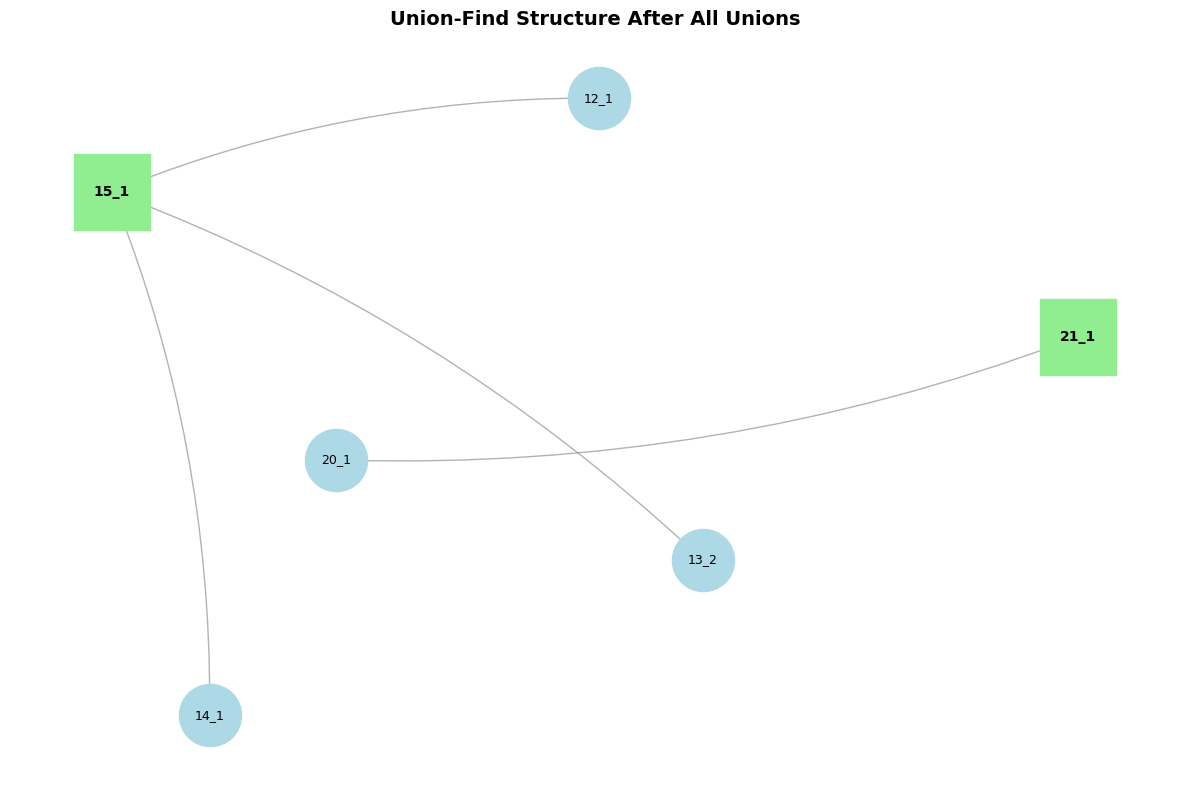

Root nodes: ['21_1', '15_1']


In [3]:
def visualize_union_find_structure(uf, title="Union-Find Structure"):
    """Visualize the Union-Find parent relationships as a directed graph"""
    G = nx.DiGraph()
    
    # Add all nodes
    for node in uf.parent.keys():
        G.add_node(node)
    
    # Add edges (parent relationships)
    for child, parent in uf.parent.items():
        if child != parent:  # Don't show self-loops for roots
            G.add_edge(child, parent)
    
    # Identify roots (nodes that point to themselves)
    roots = [node for node in G.nodes() if uf.parent[node] == node]
    
    # Layout
    pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
    
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', 
                          arrows=True, arrowsize=20, arrowstyle='->', 
                          connectionstyle='arc3,rad=0.1', alpha=0.6)
    
    # Draw non-root nodes
    non_roots = [n for n in G.nodes() if n not in roots]
    if non_roots:
        nx.draw_networkx_nodes(G, pos, nodelist=non_roots, 
                              node_color='lightblue', node_size=2000, 
                              ax=ax, node_shape='o')
        nx.draw_networkx_labels(G, pos, {n: n for n in non_roots}, 
                              font_size=9, ax=ax)
    
    # Draw root nodes (highlighted)
    if roots:
        nx.draw_networkx_nodes(G, pos, nodelist=roots, 
                              node_color='lightgreen', node_size=3000, 
                              ax=ax, node_shape='s')
        nx.draw_networkx_labels(G, pos, {n: n for n in roots}, 
                              font_size=10, font_weight='bold', ax=ax)
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    return G, roots

# Visualize the final structure
G, roots = visualize_union_find_structure(uf, "Union-Find Structure After All Unions")
print(f"Root nodes: {roots}")

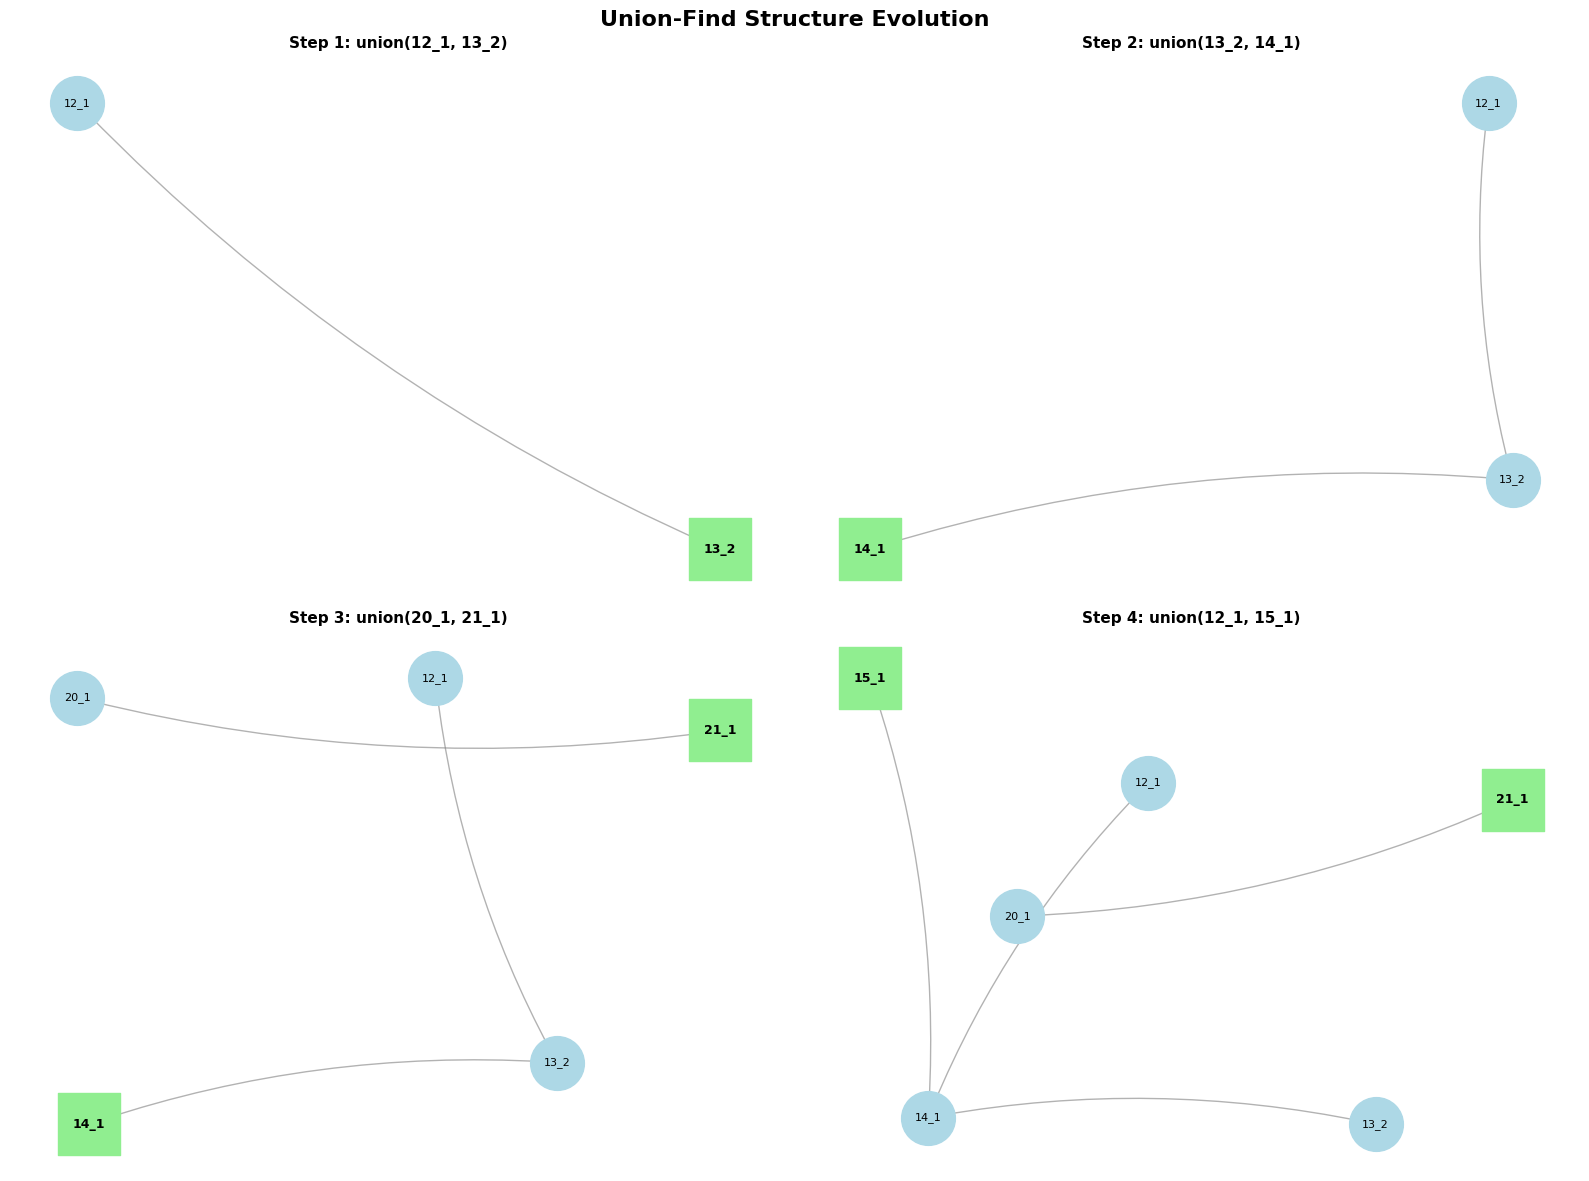

In [4]:
def visualize_union_steps(uf_visualizer, unions):
    """Visualize the Union-Find structure after each union operation"""
    uf_step = UnionFindVisualizer()
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    for idx, (a, b) in enumerate(unions):
        uf_step.union(a, b)
        
        G = nx.DiGraph()
        for node in uf_step.parent.keys():
            G.add_node(node)
        
        for child, parent in uf_step.parent.items():
            if child != parent:
                G.add_edge(child, parent)
        
        roots = [node for node in G.nodes() if uf_step.parent[node] == node]
        
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        ax = axes[idx]
        
        # Draw edges
        nx.draw_networkx_edges(G, pos, ax=ax, edge_color='gray', 
                              arrows=True, arrowsize=15, arrowstyle='->',
                              connectionstyle='arc3,rad=0.1', alpha=0.6)
        
        # Draw non-root nodes
        non_roots = [n for n in G.nodes() if n not in roots]
        if non_roots:
            nx.draw_networkx_nodes(G, pos, nodelist=non_roots, 
                                  node_color='lightblue', node_size=1500, ax=ax)
            nx.draw_networkx_labels(G, pos, {n: n for n in non_roots}, 
                                    font_size=8, ax=ax)
        
        # Draw root nodes
        if roots:
            nx.draw_networkx_nodes(G, pos, nodelist=roots, 
                                  node_color='lightgreen', node_size=2000, 
                                  ax=ax, node_shape='s')
            nx.draw_networkx_labels(G, pos, {n: n for n in roots}, 
                                    font_size=9, font_weight='bold', ax=ax)
        
        ax.set_title(f"Step {idx+1}: union({a}, {b})", fontsize=11, fontweight='bold')
        ax.axis('off')
    
    plt.suptitle("Union-Find Structure Evolution", fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

# Visualize step-by-step union operations
visualize_union_steps(uf, unions)

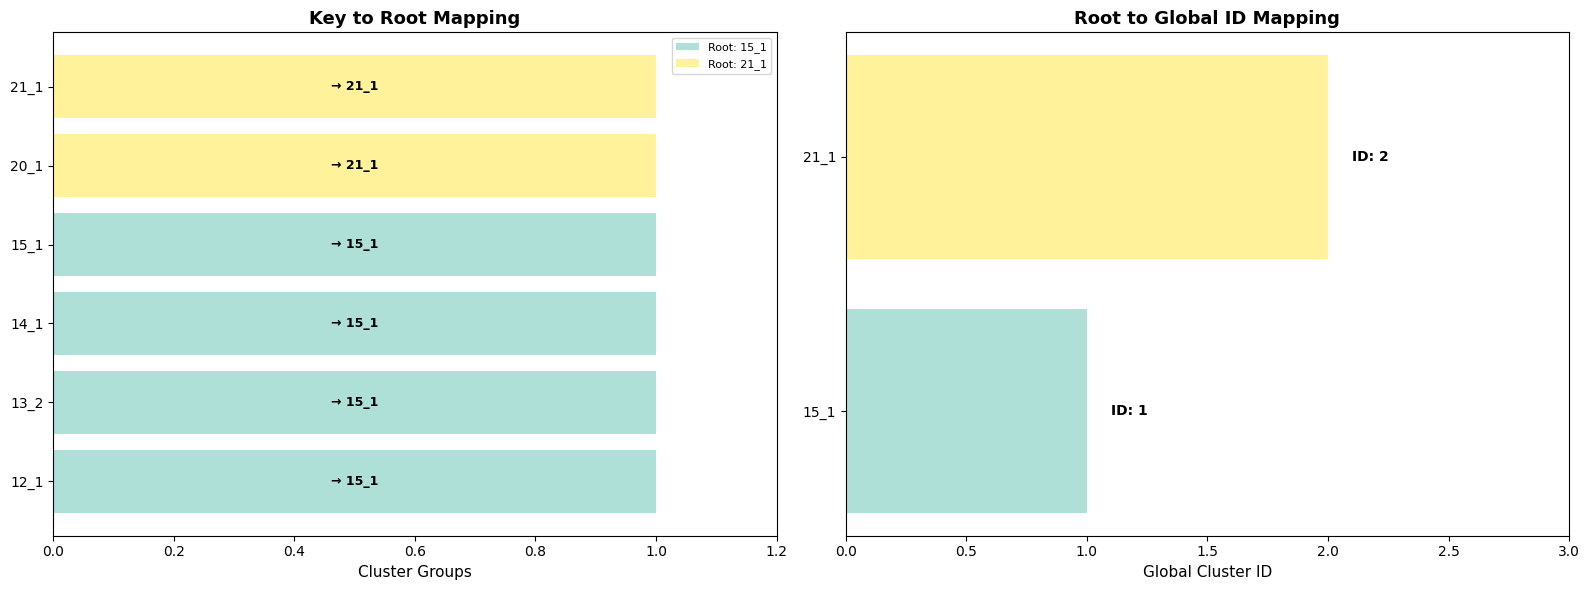


Final Local Cluster to Global Cluster Mapping
Local Cluster        Root            Global ID 
------------------------------------------------------------
12_1                 15_1            1         
13_2                 15_1            1         
14_1                 15_1            1         
15_1                 15_1            1         
20_1                 21_1            2         
21_1                 21_1            2         


In [5]:
def visualize_mappings(uf, key_to_root, root_to_global):
    """Visualize the key-to-root and root-to-global mappings"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Key to Root mapping
    keys = sorted(key_to_root.keys())
    roots_list = [key_to_root[k] for k in keys]
    
    # Create color mapping for roots
    unique_roots = sorted(set(roots_list))
    root_colors = plt.cm.Set3(np.linspace(0, 1, len(unique_roots)))
    root_color_map = {root: root_colors[i] for i, root in enumerate(unique_roots)}
    
    y_pos = np.arange(len(keys))
    colors = [root_color_map[key_to_root[k]] for k in keys]
    
    ax1.barh(y_pos, [1]*len(keys), color=colors, alpha=0.7)
    ax1.set_yticks(y_pos)
    ax1.set_yticklabels(keys)
    ax1.set_xlabel('Cluster Groups', fontsize=11)
    ax1.set_title('Key to Root Mapping', fontsize=13, fontweight='bold')
    ax1.set_xlim(0, 1.2)
    
    # Add root labels
    for i, (key, root) in enumerate(zip(keys, roots_list)):
        ax1.text(0.5, i, f'→ {root}', va='center', ha='center', 
                fontsize=9, fontweight='bold')
    
    # Add legend for roots
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=root_color_map[r], 
                                     alpha=0.7, label=f'Root: {r}') 
                      for r in unique_roots]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=8)
    
    # Plot 2: Root to Global ID mapping
    roots_sorted = sorted(root_to_global.keys())
    global_ids = [root_to_global[r] for r in roots_sorted]
    
    colors_global = [root_color_map[r] for r in roots_sorted]
    y_pos2 = np.arange(len(roots_sorted))
    
    bars = ax2.barh(y_pos2, global_ids, color=colors_global, alpha=0.7)
    ax2.set_yticks(y_pos2)
    ax2.set_yticklabels(roots_sorted)
    ax2.set_xlabel('Global Cluster ID', fontsize=11)
    ax2.set_title('Root to Global ID Mapping', fontsize=13, fontweight='bold')
    ax2.set_xlim(0, max(global_ids) + 1)
    
    # Add value labels on bars
    for i, (bar, gid) in enumerate(zip(bars, global_ids)):
        ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                f'ID: {gid}', va='center', fontsize=10, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print final mapping table
    print("\n" + "="*60)
    print("Final Local Cluster to Global Cluster Mapping")
    print("="*60)
    print(f"{'Local Cluster':<20} {'Root':<15} {'Global ID':<10}")
    print("-"*60)
    for key in sorted(key_to_root.keys()):
        root = key_to_root[key]
        gid = root_to_global[root]
        print(f"{key:<20} {root:<15} {gid:<10}")

# Visualize mappings
visualize_mappings(uf, key_to_root, root_to_global)

In [ ]:
def visualize_cluster_groups(uf, key_to_root, root_to_global):
    """Visualize clusters grouped by their global IDs"""
    # Group keys by their global ID
    groups = defaultdict(list)
    for key in key_to_root.keys():
        root = key_to_root[key]
        global_id = root_to_global[root]
        groups[global_id].append(key)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create visualization
    y_offset = 0
    colors = plt.cm.tab10(np.linspace(0, 1, len(groups)))
    
    for idx, (global_id, keys) in enumerate(sorted(groups.items())):
        # Draw box for this global cluster
        num_keys = len(keys)
        box_height = num_keys * 0.8 + 0.4
        
        box = FancyBboxPatch((0, y_offset), 1, box_height,
                           boxstyle="round,pad=0.1", 
                           facecolor=colors[idx], alpha=0.3,
                           edgecolor='black', linewidth=2)
        ax.add_patch(box)
        
        # Add global ID label
        ax.text(0.5, y_offset + box_height - 0.2, 
               f'Global Cluster ID: {global_id}', 
               ha='center', va='top', fontsize=12, fontweight='bold')
        
        # Add local clusters
        for i, key in enumerate(sorted(keys)):
            ax.text(0.5, y_offset + box_height - 0.5 - i*0.8, 
                   f'  • {key}', ha='center', va='top', fontsize=10)
        
        y_offset += box_height + 0.5
    
    ax.set_xlim(-0.2, 1.2)
    ax.set_ylim(-0.2, y_offset)
    ax.set_title('Clusters Grouped by Global ID', fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("Cluster Grouping Summary")
    print("="*60)
    for global_id, keys in sorted(groups.items()):
        print(f"\nGlobal Cluster ID {global_id}:")
        print(f"  Contains {len(keys)} local cluster(s): {', '.join(sorted(keys))}")

# Visualize cluster groups
visualize_cluster_groups(uf, key_to_root, root_to_global)

### Understanding the Union-Find Process

The visualization above shows:

1. **Union Operations**: Each step merges two clusters by connecting their roots
2. **Parent Structure**: Shows the tree structure where each node points to its parent
3. **Root Nodes**: Green squares represent root nodes (nodes that point to themselves)
4. **Key-to-Root Mapping**: After path compression, each key maps to its root representative
5. **Global ID Assignment**: Each root gets assigned a unique global cluster ID
6. **Final Mapping**: All local clusters are mapped to their corresponding global cluster IDs

This process is crucial in distributed DBSCAN because:
- Clusters may span multiple cells (e.g., `12_1` and `13_2` are in different cells but connected)
- Union-Find efficiently merges these connected clusters
- Global IDs provide a consistent cluster labeling across all partitions

## Setup: Simple Dataset for Demonstration

We'll use a small dataset with points that span cell boundaries to demonstrate key concepts.

In [4]:
# Expanded dataset: 2x2 grid with more points spanning boundaries
points = [
    # Cell (0,0) - interior and boundary points
    {'id': 0, 'x': 0.10, 'y': 0.10},  # Interior
    {'id': 1, 'x': 0.15, 'y': 0.15},  # Interior
    {'id': 2, 'x': 0.20, 'y': 0.20},  # Interior
    {'id': 3, 'x': 0.25, 'y': 0.25},  # Near right boundary (will create ghost in Cell 1,0)
    {'id': 4, 'x': 0.20, 'y': 0.45},  # Near top boundary (will create ghost in Cell 0,1)
    
    # Cell (1,0) - boundary points
    {'id': 5, 'x': 0.35, 'y': 0.25},  # Near left boundary (ghost from Cell 0,0)
    {'id': 6, 'x': 0.45, 'y': 0.20},  # Interior
    {'id': 7, 'x': 0.55, 'y': 0.15},  # Interior
    {'id': 8, 'x': 0.65, 'y': 0.25},  # Interior
    {'id': 9, 'x': 0.60, 'y': 0.45},  # Near top boundary (will create ghost in Cell 1,1)
    
    # Cell (0,1) - boundary points
    {'id': 10, 'x': 0.15, 'y': 0.55},  # Interior
    {'id': 11, 'x': 0.25, 'y': 0.65},  # Near right boundary (will create ghost in Cell 1,1)
    {'id': 12, 'x': 0.20, 'y': 0.75},  # Interior
    {'id': 13, 'x': 0.10, 'y': 0.80},  # Interior
    
    # Cell (1,1) - boundary points
    {'id': 14, 'x': 0.35, 'y': 0.75},  # Near left boundary (ghost from Cell 0,1)
    {'id': 15, 'x': 0.45, 'y': 0.70},  # Interior
    {'id': 16, 'x': 0.55, 'y': 0.65},  # Interior
    {'id': 17, 'x': 0.65, 'y': 0.75},  # Interior
    {'id': 18, 'x': 0.75, 'y': 0.75},  # Interior
]

eps = 0.15
minPts = 2
cellFactor = 1.0
cell_size = eps * cellFactor  # used for buffer threshold only

# Grid configuration (2x2) - grid cell size must match drawn grid
num_cols = 2
num_rows = 2
min_x, max_x = 0.0, 1.0
min_y, max_y = 0.0, 1.0
grid_cell_size_x = (max_x - min_x) / num_cols  # 0.5 for 2x2
grid_cell_size_y = (max_y - min_y) / num_rows

print(f"Dataset: {len(points)} points")
print(f"eps = {eps}, minPts = {minPts}")
print(f"Grid cell size = {grid_cell_size_x} x {grid_cell_size_y}")
print(f"Buffer (ghost threshold) = {eps * 1.0}")

Dataset: 19 points
eps = 0.15, minPts = 2
Cell size = 0.15


---

## Figure 1: Grid Partitioning

**Java Code:** `ExecuteDBSCAN.java` lines 54-60, 67-72

The space is divided into a grid of cells. Each cell processes points independently.

---
## KD-Tree: Finding Nearby Points Quickly

**Why we need it:** DBSCAN often asks “which points are within distance **eps** of this point?” Checking every point is slow. A **KD-Tree** answers that question much faster.

**Idea in one sentence:** We repeatedly cut the plane with **vertical** and **horizontal** lines (using the median x or y of the points). That divides the space into regions so we can skip regions that are too far away.

### Building the tree (what you see as gray lines)
1. **First cut:** Split all points by **x**: sort by x, take the middle value → draw a **vertical** line there.
2. **Second cut:** On each side, split by **y**: take the middle y → draw **horizontal** lines.
3. We keep alternating **x** and **y** until each region has few points.  
   → The **gray dashed lines** in the figure are these cuts.

### Using the tree (radius search)
- We have a **query point** (orange star) and a **radius** (orange circle).
- The tree only looks inside regions that the circle can touch. It skips regions that are completely outside the circle.  
   → **Green points** are the neighbors found.

*Code: `KDTree.java`*

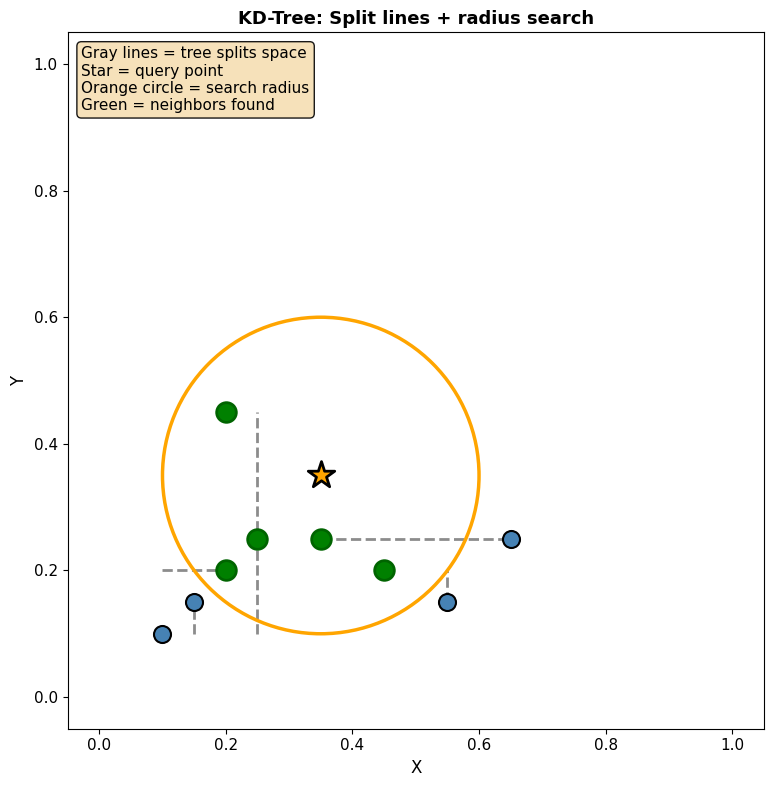

In [27]:
# --- Simple KD-Tree picture: gray lines = cuts, star = query, circle = radius, green = neighbors ---

def build_kd(pts, depth, lines_list):
    if not pts:
        return None
    dim = depth % 2  # alternate x, y
    pts_sorted = sorted(pts, key=lambda p: p[dim])
    mid = len(pts_sorted) // 2
    node_pt = pts_sorted[mid]
    split_val = node_pt[dim]
    other = 1 - dim
    lo = min(p[other] for p in pts_sorted)
    hi = max(p[other] for p in pts_sorted)
    lines_list.append((dim, split_val, lo, hi))
    left = build_kd(pts_sorted[:mid], depth + 1, lines_list)
    right = build_kd(pts_sorted[mid + 1:], depth + 1, lines_list)
    return (node_pt, dim, left, right)

def radius_search_kd(node, query, eps2, results):
    if node is None:
        return
    (px, py, pid), dim, left, right = node[0], node[1], node[2], node[3]
    qx, qy = query[0], query[1]
    if (px - qx) ** 2 + (py - qy) ** 2 <= eps2:
        results.append((px, py, pid))
    diff = (qx - px) if dim == 0 else (qy - py)
    near = left if diff <= 0 else right
    far = right if diff <= 0 else left
    radius_search_kd(near, query, eps2, results)
    if diff * diff <= eps2:
        radius_search_kd(far, query, eps2, results)

# Use a small subset so the split lines are easy to see (first 9 points)
pts_simple = [(p['x'], p['y'], p['id']) for p in points[:9]]
kd_lines = []
root = build_kd(pts_simple, 0, kd_lines)

query_pt = (0.35, 0.35)
eps_kd = 0.38
neighbors = []
radius_search_kd(root, query_pt, eps_kd ** 2, neighbors)

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')

# 1. Gray dashed = splitting lines (how the tree cuts the plane)
for (dim, split_val, lo, hi) in kd_lines:
    if dim == 0:
        ax.plot([split_val, split_val], [lo, hi], 'gray', linestyle='--', linewidth=2, alpha=0.9)
    else:
        ax.plot([lo, hi], [split_val, split_val], 'gray', linestyle='--', linewidth=2, alpha=0.9)

# 2. All points (small set)
xs = [p[0] for p in pts_simple]
ys = [p[1] for p in pts_simple]
ax.scatter(xs, ys, s=150, c='steelblue', edgecolors='black', linewidth=1.5, zorder=3)

# 3. Query = orange star, circle = search radius
ax.scatter([query_pt[0]], [query_pt[1]], s=400, c='orange', edgecolors='black', linewidth=2, zorder=5, marker='*')
circle = plt.Circle(query_pt, eps_kd, fill=False, edgecolor='orange', linewidth=2.5, zorder=2)
ax.add_patch(circle)

# 4. Green = neighbors inside the circle
if neighbors:
    ax.scatter([n[0] for n in neighbors], [n[1] for n in neighbors], s=200, c='green', edgecolors='darkgreen', linewidth=2, zorder=4)

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('X', fontsize=12)
ax.set_ylabel('Y', fontsize=12)
ax.set_title('KD-Tree: Split lines + radius search', fontsize=13, fontweight='bold')

# Plain-English legend on the figure
ax.text(0.02, 0.98, 'Gray lines = tree splits space\nStar = query point\nOrange circle = search radius\nGreen = neighbors found', 
        transform=ax.transAxes, fontsize=11, verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.9))
plt.tight_layout()
plt.show()

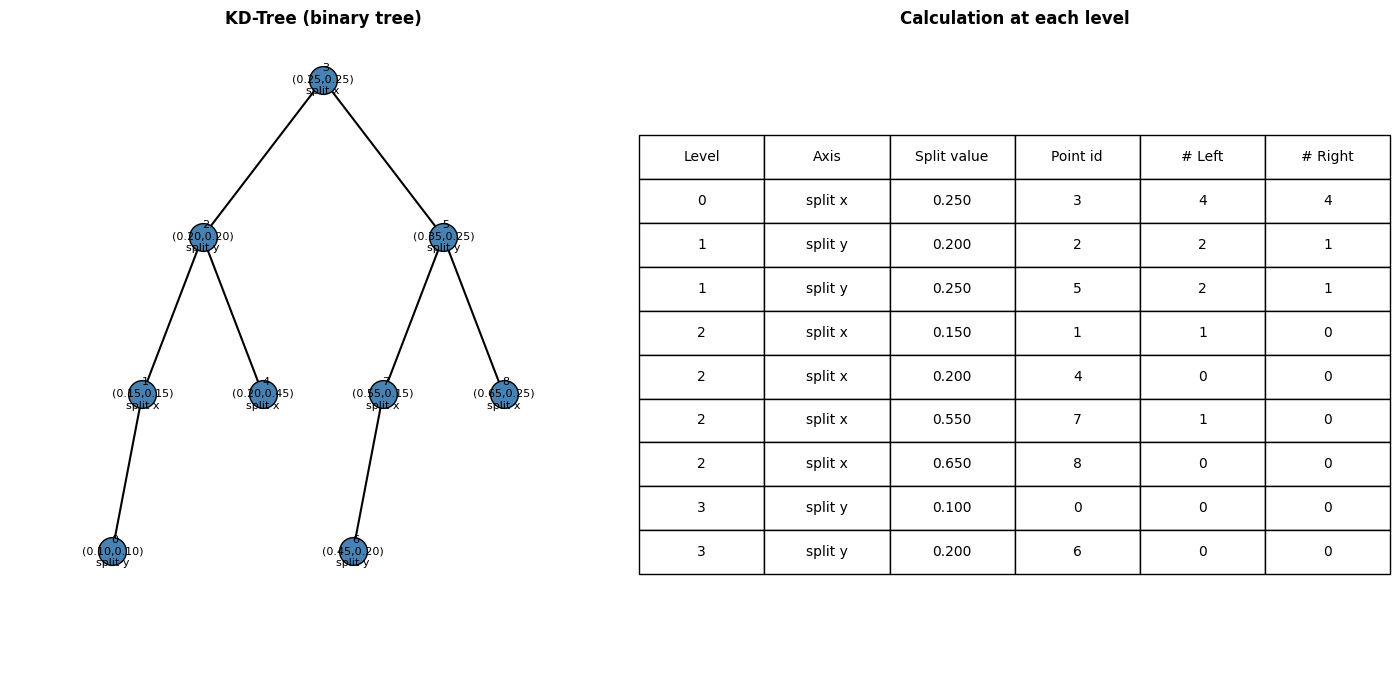

In [31]:
# --- Binary tree view of KD-Tree with per-level calculation ---
# Build tree and record at each node: (depth, dim, split_val, point, n_left, n_right)
level_calcs = []

def build_kd_with_calcs(pts, depth, lines_list):
    if not pts:
        return None
    dim = depth % 2
    pts_sorted = sorted(pts, key=lambda p: p[dim])
    mid = len(pts_sorted) // 2
    node_pt = pts_sorted[mid]
    split_val = node_pt[dim]
    n_left, n_right = len(pts_sorted[:mid]), len(pts_sorted[mid + 1:])
    level_calcs.append((depth, dim, split_val, node_pt, n_left, n_right))
    other = 1 - dim
    lo = min(p[other] for p in pts_sorted)
    hi = max(p[other] for p in pts_sorted)
    lines_list.append((dim, split_val, lo, hi))
    left = build_kd_with_calcs(pts_sorted[:mid], depth + 1, lines_list)
    right = build_kd_with_calcs(pts_sorted[mid + 1:], depth + 1, lines_list)
    return (node_pt, dim, left, right)

pts_bt = [(p['x'], p['y'], p['id']) for p in points[:9]]
level_calcs.clear()
root_bt = build_kd_with_calcs(pts_bt, 0, [])

# Assign (x,y) layout for each node by depth and horizontal slot
nodes_list = []
def layout_tree(node, depth, left, right):
    if node is None:
        return
    mid = (left + right) / 2
    nodes_list.append((node, depth, mid, depth))
    (_, _, l, r) = node
    layout_tree(l, depth + 1, left, mid)
    layout_tree(r, depth + 1, mid, right)

layout_tree(root_bt, 0, 0.0, 1.0)

# Plot: tree on left, level table on right
fig, (ax_tree, ax_tbl) = plt.subplots(1, 2, figsize=(14, 7))
ax_tree.set_axis_off()
ax_tbl.set_axis_off()

# Draw edges (from parent to child using nodes_list positions)
for node, depth, x, y in nodes_list:
    (_, _, left_child, right_child) = node
    px, py = x, -y
    for child in [left_child, right_child]:
        if child is not None:
            cx, cy = next(((mx, -d) for (n, d, mx, my) in nodes_list if n is child), (x, -(depth + 1)))
            ax_tree.plot([px, cx], [py, cy], 'k', lw=1.5, zorder=0)

# Draw nodes with labels
for node, depth, x, y in nodes_list:
    (pt, dim, _, _) = node
    xx, yy = pt[0], pt[1]
    pid = pt[2]
    ax_tree.scatter([x], [-y], s=400, c='steelblue', edgecolors='black', zorder=2)
    dim_name = 'x' if dim == 0 else 'y'
    ax_tree.text(x, -y, f'  {pid}\n({xx:.2f},{yy:.2f})\nsplit {dim_name}', ha='center', va='center', fontsize=8)

ax_tree.set_xlim(-0.15, 1.15)
ax_tree.set_ylim(-3.8, 0.3)
ax_tree.set_title('KD-Tree (binary tree)', fontsize=12, fontweight='bold')

# Level calculations table
ax_tbl.set_title('Calculation at each level', fontsize=12, fontweight='bold')
rows = []
for depth in range(max(d for d, *_ in level_calcs) + 1):
    level_nodes = [(d, dim, split_val, pt, n_l, n_r) for (d, dim, split_val, pt, n_l, n_r) in level_calcs if d == depth]
    for (d, dim, split_val, pt, n_l, n_r) in level_nodes:
        dim_name = 'x' if dim == 0 else 'y'
        rows.append((depth, f'split {dim_name}', f'{split_val:.3f}', pt[2], n_l, n_r))

# Table
col_labels = ['Level', 'Axis', 'Split value', 'Point id', '# Left', '# Right']
cell_text = [[str(r[0]), r[1], r[2], str(r[3]), str(r[4]), str(r[5])] for r in rows]
tbl = ax_tbl.table(cellText=cell_text, colLabels=col_labels, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.2)
plt.tight_layout()
plt.show()

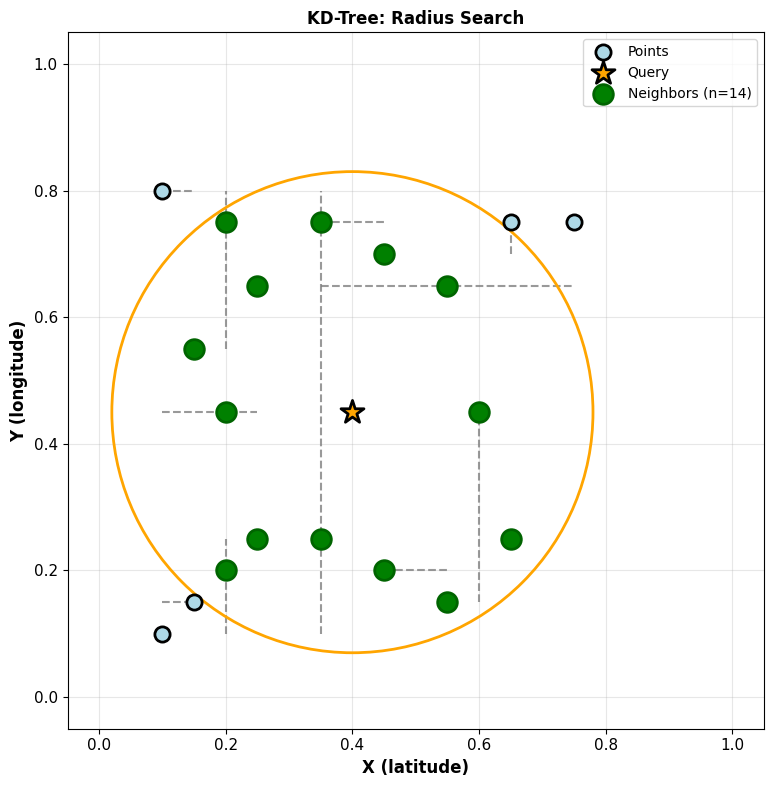

In [29]:
# KD-Tree visualization: build (same logic as KDTree.java), collect splitting lines, then radius search

def build_kd(pts, depth, lines_list):
    """Build KD-tree and record splitting lines. pts = list of (x, y, id)."""
    if not pts:
        return None
    dim = depth % 2  # 0 = x (latitude), 1 = y (longitude) — matches Java
    pts_sorted = sorted(pts, key=lambda p: p[dim])
    mid = len(pts_sorted) // 2
    node_pt = pts_sorted[mid]
    split_val = node_pt[dim]
    other = 1 - dim
    lo = min(p[other] for p in pts_sorted)
    hi = max(p[other] for p in pts_sorted)
    lines_list.append((dim, split_val, lo, hi))
    left = build_kd(pts_sorted[:mid], depth + 1, lines_list)
    right = build_kd(pts_sorted[mid + 1:], depth + 1, lines_list)
    return (node_pt, dim, left, right)

def radius_search_kd(node, query, eps2, results):
    """Radius search with squared distance, matching KDTree.java radiusSearch()."""
    if node is None:
        return
    (px, py, pid), dim, left, right = node[0], node[1], node[2], node[3]
    qx, qy = query[0], query[1]
    dist2 = (px - qx) ** 2 + (py - qy) ** 2
    if dist2 <= eps2:
        results.append((px, py, pid))
    diff = (qx - px) if dim == 0 else (qy - py)
    near = left if diff <= 0 else right
    far = right if diff <= 0 else left
    radius_search_kd(near, query, eps2, results)
    if diff * diff <= eps2:
        radius_search_kd(far, query, eps2, results)

# Use notebook points: x = latitude, y = longitude (as in Point.java)
pts_for_kd = [(p['x'], p['y'], p['id']) for p in points]
kd_lines = []
root = build_kd(pts_for_kd, 0, kd_lines)

# Radius search example: query near center, eps same scale as notebook
query_pt = (0.4, 0.45)
eps_kd = 0.38
eps2 = eps_kd * eps_kd
neighbors = []
radius_search_kd(root, query_pt, eps2, neighbors)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')

# Draw splitting lines (partitioning)
for (dim, split_val, lo, hi) in kd_lines:
    if dim == 0:
        ax.plot([split_val, split_val], [lo, hi], 'gray', linestyle='--', linewidth=1.5, alpha=0.8)
    else:
        ax.plot([lo, hi], [split_val, split_val], 'gray', linestyle='--', linewidth=1.5, alpha=0.8)

# All points
xs = [p['x'] for p in points]
ys = [p['y'] for p in points]
ax.scatter(xs, ys, s=120, c='lightblue', edgecolors='black', linewidth=2, zorder=3, label='Points')

# Query point
ax.scatter([query_pt[0]], [query_pt[1]], s=300, c='orange', edgecolors='black', linewidth=2, zorder=5, marker='*', label='Query')

# Radius circle
circle = plt.Circle(query_pt, eps_kd, fill=False, edgecolor='orange', linewidth=2, linestyle='-', zorder=2)
ax.add_patch(circle)

# Neighbors found by radius search
if neighbors:
    nxs, nys = [n[0] for n in neighbors], [n[1] for n in neighbors]
    ax.scatter(nxs, nys, s=200, c='green', edgecolors='darkgreen', linewidth=2, zorder=4, label=f'Neighbors (n={len(neighbors)})')

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_xlabel('X (latitude)', fontsize=12, fontweight='bold')
ax.set_ylabel('Y (longitude)', fontsize=12, fontweight='bold')
ax.set_title('KD-Tree: Radius Search', fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

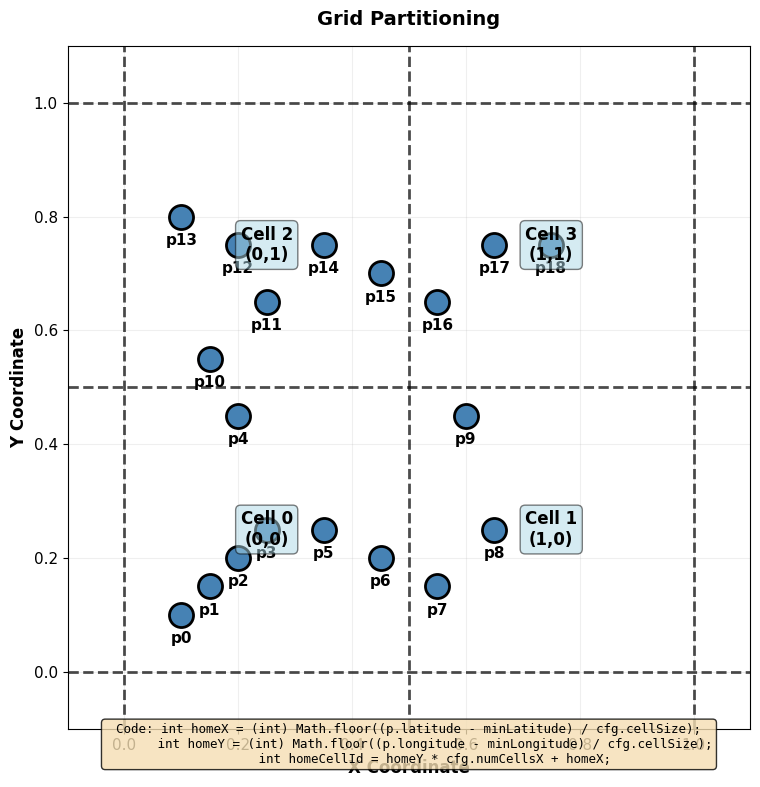

In [6]:
fig, ax = plt.subplots(figsize=(8, 8))

# Draw grid
x_grid_lines = np.linspace(min_x, max_x, num_cols + 1)
y_grid_lines = np.linspace(min_y, max_y, num_rows + 1)

for x_line in x_grid_lines:
    ax.axvline(x_line, color='black', linestyle='--', linewidth=2, alpha=0.7)
for y_line in y_grid_lines:
    ax.axhline(y_line, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Plot all points
for p in points:
    ax.scatter(p['x'], p['y'], s=300, c='steelblue', edgecolors='black', linewidth=2, zorder=3)
    ax.text(p['x'], p['y']-0.05, f"p{p['id']}", ha='center', fontsize=11, fontweight='bold')

# Label cells
cell_id = 0
for j, y_start in enumerate(y_grid_lines[:-1]):
    for i, x_start in enumerate(x_grid_lines[:-1]):
        x_center = (x_start + x_grid_lines[i+1]) / 2
        y_center = (y_start + y_grid_lines[j+1]) / 2
        ax.text(x_center, y_center, f'Cell {cell_id}\n({i},{j})', 
                ha='center', va='center', fontsize=12, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
        cell_id += 1

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_aspect('equal')
ax.set_xlabel('X Coordinate', fontsize=12, fontweight='bold')
ax.set_ylabel('Y Coordinate', fontsize=12, fontweight='bold')
ax.set_title('Grid Partitioning', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.2)

# Code explanation box
ax.text(0.5, -0.05,
        "Code: int homeX = (int) Math.floor((p.latitude - minLatitude) / cfg.cellSize);\n" +
        "       int homeY = (int) Math.floor((p.longitude - minLongitude) / cfg.cellSize);\n" +
        "       int homeCellId = homeY * cfg.numCellsX + homeX;",
        transform=ax.transAxes,
        fontsize=9,
        ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        family='monospace')

plt.tight_layout()
plt.show()

---

## Figure 2: Home Cell Assignment

**Java Code:** `ExecuteDBSCAN.java` lines 73-77

Each point is assigned to its **home cell** based on its geometric location.

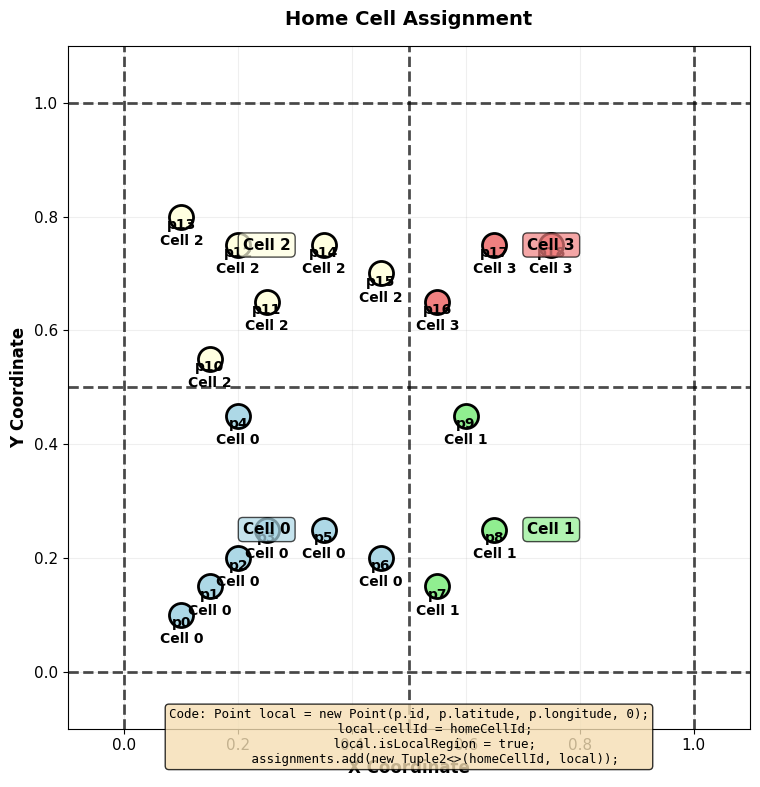

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))

# Draw grid
for x_line in x_grid_lines:
    ax.axvline(x_line, color='black', linestyle='--', linewidth=2, alpha=0.7)
for y_line in y_grid_lines:
    ax.axhline(y_line, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Grid cell size (must match drawn grid for correct home cell)
grid_cell_size_x = (max_x - min_x) / num_cols
grid_cell_size_y = (max_y - min_y) / num_rows

# Color code points by their home cell
cell_colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']

def get_home_cell(x, y):
    cell_x = int(np.floor((x - min_x) / grid_cell_size_x))
    cell_y = int(np.floor((y - min_y) / grid_cell_size_y))
    cell_x = max(0, min(cell_x, num_cols - 1))
    cell_y = max(0, min(cell_y, num_rows - 1))
    return cell_y * num_cols + cell_x

for p in points:
    home_cell = get_home_cell(p['x'], p['y'])
    ax.scatter(p['x'], p['y'], s=300, c=cell_colors[home_cell], 
               edgecolors='black', linewidth=2, zorder=3)
    ax.text(p['x'], p['y']-0.05, f"p{p['id']}\nCell {home_cell}", 
            ha='center', fontsize=10, fontweight='bold')

# Label cells
cell_id = 0
for j, y_start in enumerate(y_grid_lines[:-1]):
    for i, x_start in enumerate(x_grid_lines[:-1]):
        x_center = (x_start + x_grid_lines[i+1]) / 2
        y_center = (y_start + y_grid_lines[j+1]) / 2
        ax.text(x_center, y_center, f'Cell {cell_id}', 
                ha='center', va='center', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round', facecolor=cell_colors[cell_id], alpha=0.7))
        cell_id += 1

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_aspect('equal')
ax.set_xlabel('X Coordinate', fontsize=12, fontweight='bold')
ax.set_ylabel('Y Coordinate', fontsize=12, fontweight='bold')
ax.set_title('Home Cell Assignment', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.2)

# Code explanation
ax.text(0.5, -0.05,
        "Code: Point local = new Point(p.id, p.latitude, p.longitude, 0);\n" +
        "       local.cellId = homeCellId;\n" +
        "       local.isLocalRegion = true;\n" +
        "       assignments.add(new Tuple2<>(homeCellId, local));",
        transform=ax.transAxes,
        fontsize=9,
        ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        family='monospace')

plt.tight_layout()
plt.show()

---

## Figure 3: Ghost Point Replication (Boundary Handling)

**Java Code:** `ExecuteDBSCAN.java` lines 78-126

**Local Ghost Points:** Points within a `buffer` distance (typically `eps * bufferFactor`) from any cell boundary are **replicated as ghost points** in the neighboring cell(s). 

**Why Ghost Points?** When a cluster spans multiple cells, each cell runs DBSCAN independently. Without ghost points, points near boundaries might not find neighbors in adjacent cells, causing the cluster to be incorrectly split. Ghost points ensure that:
- Points near **left/right boundaries** are replicated in the cell to the left/right
- Points near **top/bottom boundaries** are replicated in the cell above/below
- Points near **corners** can be replicated in up to 3 neighboring cells

**Buffer Zones:** The red shaded areas show buffer zones on all four sides of each cell. Any point falling within these zones creates ghost copies in adjacent cells. This ensures clusters crossing boundaries are detected correctly during local DBSCAN execution.

/var/folders/0c/bg7lszj94cz0b84y_45p31x80000gn/T/ipykernel_7620/3277756127.py:98: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(Rectangle((x_start - buffer, y_start), buffer, y_end - y_start, **buf_style))
/var/folders/0c/bg7lszj94cz0b84y_45p31x80000gn/T/ipykernel_7620/3277756127.py:100: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(Rectangle((x_end, y_start), buffer, y_end - y_start, **buf_style))
/var/folders/0c/bg7lszj94cz0b84y_45p31x80000gn/T/ipykernel_7620/3277756127.py:102: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(Rectangle((x_start, y_start - buffer), x_end - x_start, buffer, **buf_style))
/var/folders/0c/bg7lszj94cz0b84y_45p31x80000gn/T/ipykernel_7620/3277756127.py:104: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ax.add_patch(Rectan

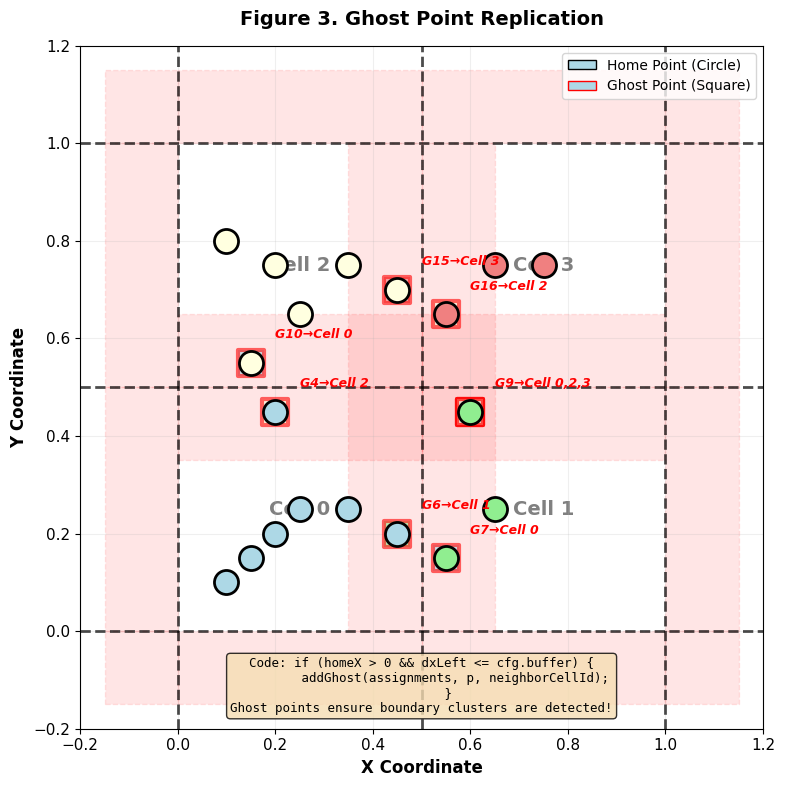

Ghost points created: 9


In [24]:
fig, ax = plt.subplots(figsize=(8, 8))

# Draw grid
for x_line in x_grid_lines:
    ax.axvline(x_line, color='black', linestyle='--', linewidth=2, alpha=0.7)
for y_line in y_grid_lines:
    ax.axhline(y_line, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Label each grid cell as 0, 1, 2, 3 (cell number in each grid)
for j in range(num_rows):
    for i in range(num_cols):
        cell_idx = j * num_cols + i
        x_center = (x_grid_lines[i] + x_grid_lines[i+1]) / 2
        y_center = (y_grid_lines[j] + y_grid_lines[j+1]) / 2
        ax.text(x_center, y_center, f"Cell {cell_idx}", ha='center', va='center', fontsize=14, fontweight='bold', color='gray', zorder=1)

# Grid cell size and home cell (self-contained for this figure)
grid_cell_size_x = (max_x - min_x) / num_cols
grid_cell_size_y = (max_y - min_y) / num_rows
cell_colors = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']

def get_home_cell(x, y):
    cell_x = int(np.floor((x - min_x) / grid_cell_size_x))
    cell_y = int(np.floor((y - min_y) / grid_cell_size_y))
    cell_x = max(0, min(cell_x, num_cols - 1))
    cell_y = max(0, min(cell_y, num_rows - 1))
    return cell_y * num_cols + cell_x

# Calculate ghost points (match Java: distance to cell boundaries <= buffer)
buffer = eps * 1.0  # bufferFactor = 1.0
ghost_assignments = {}  # (point_id, target_cell) -> True

for p in points:
    home_cell = get_home_cell(p['x'], p['y'])
    home_x = home_cell % num_cols
    home_y = home_cell // num_cols
    
    cell_min_x = min_x + home_x * grid_cell_size_x
    cell_min_y = min_y + home_y * grid_cell_size_y
    
    dx_left = p['x'] - cell_min_x
    dx_right = (cell_min_x + grid_cell_size_x) - p['x']
    dy_bottom = p['y'] - cell_min_y
    dy_top = (cell_min_y + grid_cell_size_y) - p['y']
    
    # Check neighbors
    # Cardinal neighbors (Java: ExecuteDBSCAN lines 86-101)
    if home_x > 0 and dx_left <= buffer:
        ghost_assignments[(p['id'], home_cell - 1)] = True
    if home_x < num_cols - 1 and dx_right <= buffer:
        ghost_assignments[(p['id'], home_cell + 1)] = True
    if home_y > 0 and dy_bottom <= buffer:
        ghost_assignments[(p['id'], home_cell - num_cols)] = True
    if home_y < num_rows - 1 and dy_top <= buffer:
        ghost_assignments[(p['id'], home_cell + num_cols)] = True
    # Diagonal neighbors (Java: ExecuteDBSCAN lines 104-125)
    if home_x > 0 and home_y < num_rows - 1 and dx_left <= buffer and dy_top <= buffer:
        ghost_assignments[(p['id'], home_cell + num_cols - 1)] = True  # top-left
    if home_x < num_cols - 1 and home_y < num_rows - 1 and dx_right <= buffer and dy_top <= buffer:
        ghost_assignments[(p['id'], home_cell + num_cols + 1)] = True  # top-right
    if home_x > 0 and home_y > 0 and dx_left <= buffer and dy_bottom <= buffer:
        ghost_assignments[(p['id'], home_cell - num_cols - 1)] = True  # bottom-left
    if home_x < num_cols - 1 and home_y > 0 and dx_right <= buffer and dy_bottom <= buffer:
        ghost_assignments[(p['id'], home_cell - num_cols + 1)] = True  # bottom-right

# Plot home points (circles) - no labels, only ghost points are labeled
for p in points:
    home_cell = get_home_cell(p['x'], p['y'])
    ax.scatter(p['x'], p['y'], s=300, c=cell_colors[home_cell], 
               edgecolors='black', linewidth=2, zorder=3, marker='o')

# Group ghost assignments by point_id to show target cells in one label
from collections import defaultdict
ghost_by_point = defaultdict(list)
for (point_id, target_cell), _ in ghost_assignments.items():
    ghost_by_point[point_id].append(target_cell)

# Plot ghost points (squares, red border) with label showing which cell(s) each ghost is replicated to
for (point_id, target_cell), _ in ghost_assignments.items():
    p = points[point_id]
    ax.scatter(p['x'], p['y'], s=350, c=cell_colors[target_cell], 
               edgecolors='red', linewidth=3, alpha=0.6, zorder=2, marker='s')

# Add one ghost label per point: G{id}→Cell {c1},{c2} (cell numbers 1-based)
for point_id, target_cells in ghost_by_point.items():
    p = points[point_id]
    targets_str = ','.join(str(c) for c in sorted(target_cells))
    ax.text(p['x']+0.05, p['y']+0.05, f"G{point_id}→Cell {targets_str}", ha='left', fontsize=9, 
            style='italic', color='red', fontweight='bold', clip_on=False, zorder=5)

# Draw buffer zones on all four sides of every cell (left, right, bottom, top)
buf_style = dict(fill=True, alpha=0.1, color='red', linestyle='--', edgecolor='red', linewidth=1)
for j, y_start in enumerate(y_grid_lines[:-1]):
    for i, x_start in enumerate(x_grid_lines[:-1]):
        x_end = x_grid_lines[i+1]
        y_end = y_grid_lines[j+1]
        # Left buffer strip
        ax.add_patch(Rectangle((x_start - buffer, y_start), buffer, y_end - y_start, **buf_style))
        # Right buffer strip
        ax.add_patch(Rectangle((x_end, y_start), buffer, y_end - y_start, **buf_style))
        # Bottom buffer strip
        ax.add_patch(Rectangle((x_start, y_start - buffer), x_end - x_start, buffer, **buf_style))
        # Top buffer strip
        ax.add_patch(Rectangle((x_start, y_end), x_end - x_start, buffer, **buf_style))

# Draw the four corner buffers (gaps where side buffers don't meet)
ax.add_patch(Rectangle((min_x - buffer, min_y - buffer), buffer, buffer, **buf_style))   # bottom-left
ax.add_patch(Rectangle((max_x, min_y - buffer), buffer, buffer, **buf_style))             # bottom-right
ax.add_patch(Rectangle((max_x, max_y), buffer, buffer, **buf_style))                      # top-right
ax.add_patch(Rectangle((min_x - buffer, max_y), buffer, buffer, **buf_style))             # top-left

# Extend axis limits so all four sides of buffers are visible (left/bottom to -buffer, right/top to max+buffer)
ax.set_xlim(min_x - buffer - 0.05, max_x + buffer + 0.05)
ax.set_ylim(min_y - buffer - 0.05, max_y + buffer + 0.05)
ax.set_aspect('equal')
ax.set_xlabel('X Coordinate', fontsize=12, fontweight='bold')
ax.set_ylabel('Y Coordinate', fontsize=12, fontweight='bold')
ax.set_title('Figure 3. Ghost Point Replication', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.2)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', edgecolor='black', label='Home Point (Circle)'),
    Patch(facecolor='lightblue', edgecolor='red', label='Ghost Point (Square)')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

# Code explanation (inside axes so not clipped)
ax.text(0.5, 0.02,
        "Code: if (homeX > 0 && dxLeft <= cfg.buffer) {\n" +
        "         addGhost(assignments, p, neighborCellId);\n" +
        "       }\n" +
        "Ghost points ensure boundary clusters are detected!",
        transform=ax.transAxes,
        fontsize=9,
        ha='center',
        va='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        family='monospace')

plt.tight_layout()
plt.show()

print(f"Ghost points created: {len(ghost_assignments)}")

## KDTREE

---

## Figure 4: Local DBSCAN in Each Cell

**Java Code:** `ExecuteDBSCAN.java` lines 135-152

Each cell runs **local DBSCAN** independently on its points (home + ghosts). This creates local cluster IDs.

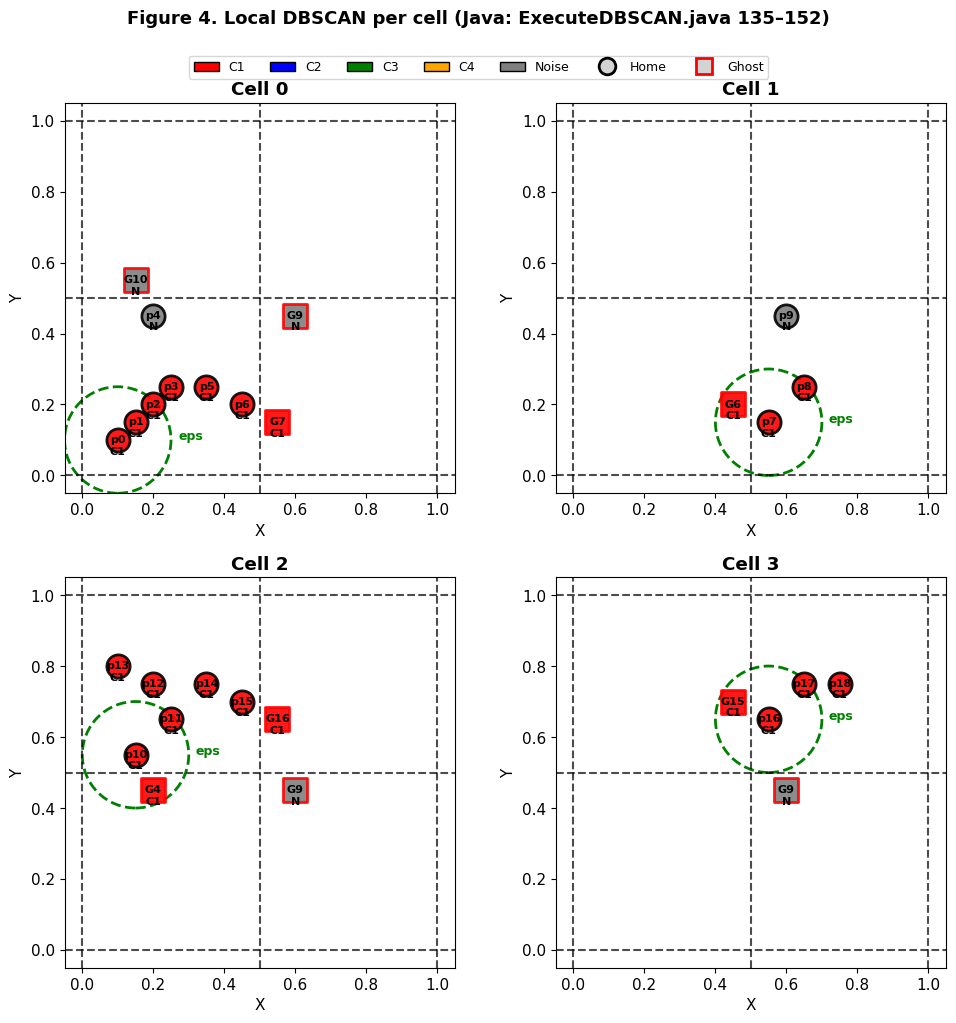

Cell 0: [(0, 1), (1, 1), (2, 1), (3, 1), (4, -1), (5, 1), (6, 1), (7, 1), (9, -1), (10, -1)]
Cell 1: [(7, 1), (8, 1), (9, -1), (6, 1)]
Cell 2: [(10, 1), (11, 1), (12, 1), (13, 1), (14, 1), (15, 1), (4, 1), (9, -1), (16, 1)]
Cell 3: [(16, 1), (17, 1), (18, 1), (9, -1), (15, 1)]


In [39]:
# --- Local DBSCAN (matches Utils.localDBSCAN in Java) ---
def local_dbscan_simple(points_in_cell, eps, minPts):
    """Run DBSCAN on points in one cell. Returns cluster_ids (list, same length as points_in_cell)."""
    n = len(points_in_cell)
    cluster_id = 1
    visited = [False] * n
    cluster_ids = [0] * n

    def distance(p1, p2):
        return np.sqrt((p1["x"] - p2["x"]) ** 2 + (p1["y"] - p2["y"]) ** 2)

    def get_neighbors(idx):
        return [i for i in range(n) if i != idx and distance(points_in_cell[idx], points_in_cell[i]) <= eps]

    for i in range(n):
        if visited[i]:
            continue
        visited[i] = True
        neighbors = get_neighbors(i)
        if len(neighbors) < minPts:
            cluster_ids[i] = -1  # Noise
            continue
        cluster_ids[i] = cluster_id
        seed_set = list(neighbors)
        j = 0
        while j < len(seed_set):
            q = seed_set[j]
            if not visited[q]:
                visited[q] = True
                q_neighbors = get_neighbors(q)
                if len(q_neighbors) >= minPts:
                    seed_set.extend(q_neighbors)
            if cluster_ids[q] == 0:
                cluster_ids[q] = cluster_id
            j += 1
        cluster_id += 1
    return cluster_ids

# Grid and home cell (same as elsewhere in notebook)
grid_cell_size_x = (max_x - min_x) / num_cols
grid_cell_size_y = (max_y - min_y) / num_rows

def get_home_cell_fig4(x, y):
    cell_x = int(np.floor((x - min_x) / grid_cell_size_x))
    cell_y = int(np.floor((y - min_y) / grid_cell_size_y))
    cell_x = max(0, min(cell_x, num_cols - 1))
    cell_y = max(0, min(cell_y, num_rows - 1))
    return cell_y * num_cols + cell_x

# Ghost assignments (same logic as Figure 3)
buffer = eps * 1.0
ghost_assignments_fig4 = {}
for p in points:
    home_cell = get_home_cell_fig4(p["x"], p["y"])
    home_x = home_cell % num_cols
    home_y = home_cell // num_cols
    cell_min_x = min_x + home_x * grid_cell_size_x
    cell_min_y = min_y + home_y * grid_cell_size_y
    dx_left = p["x"] - cell_min_x
    dx_right = (cell_min_x + grid_cell_size_x) - p["x"]
    dy_bottom = p["y"] - cell_min_y
    dy_top = (cell_min_y + grid_cell_size_y) - p["y"]
    if home_x > 0 and dx_left <= buffer:
        ghost_assignments_fig4[(p["id"], home_cell - 1)] = True
    if home_x < num_cols - 1 and dx_right <= buffer:
        ghost_assignments_fig4[(p["id"], home_cell + 1)] = True
    if home_y > 0 and dy_bottom <= buffer:
        ghost_assignments_fig4[(p["id"], home_cell - num_cols)] = True
    if home_y < num_rows - 1 and dy_top <= buffer:
        ghost_assignments_fig4[(p["id"], home_cell + num_cols)] = True
    if home_x > 0 and home_y < num_rows - 1 and dx_left <= buffer and dy_top <= buffer:
        ghost_assignments_fig4[(p["id"], home_cell + num_cols - 1)] = True
    if home_x < num_cols - 1 and home_y < num_rows - 1 and dx_right <= buffer and dy_top <= buffer:
        ghost_assignments_fig4[(p["id"], home_cell + num_cols + 1)] = True
    if home_x > 0 and home_y > 0 and dx_left <= buffer and dy_bottom <= buffer:
        ghost_assignments_fig4[(p["id"], home_cell - num_cols - 1)] = True
    if home_x < num_cols - 1 and home_y > 0 and dx_right <= buffer and dy_bottom <= buffer:
        ghost_assignments_fig4[(p["id"], home_cell - num_cols + 1)] = True

# Run local DBSCAN per cell
cell_clusters = {}
for cell_id in range(num_rows * num_cols):
    cell_points = []
    point_indices = []
    for idx, p in enumerate(points):
        if get_home_cell_fig4(p["x"], p["y"]) == cell_id:
            cell_points.append(p)
            point_indices.append(idx)
    for (pid, target_cell), _ in ghost_assignments_fig4.items():
        if target_cell == cell_id:
            cell_points.append(points[pid])
            point_indices.append(pid)
    if cell_points:
        cluster_ids = local_dbscan_simple(cell_points, eps, minPts)
        cell_clusters[cell_id] = [(point_indices[i], cluster_ids[i]) for i in range(len(cell_points))]

# --- Figure 4: one subplot per cell, with eps radius and proper legend icons ---
from matplotlib.lines import Line2D
x_grid = np.linspace(min_x, max_x, num_cols + 1)
y_grid = np.linspace(min_y, max_y, num_rows + 1)
cluster_colors_map = {1: "red", 2: "blue", 3: "green", 4: "orange", -1: "gray"}

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 10))
axes = np.atleast_2d(axes)
for j in range(num_rows):
    for i in range(num_cols):
        ax = axes[j, i]
        cell_id = j * num_cols + i
        for x_line in x_grid:
            ax.axvline(x_line, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
        for y_line in y_grid:
            ax.axhline(y_line, color="black", linestyle="--", linewidth=1.5, alpha=0.7)
        if cell_id not in cell_clusters:
            ax.set_xlim(min_x - 0.05, max_x + 0.05)
            ax.set_ylim(min_y - 0.05, max_y + 0.05)
            ax.set_aspect("equal")
            ax.set_title(f"Cell {cell_id}", fontweight="bold")
            continue
        # Eps radius: draw around the first point in this cell so the neighborhood is clear
        first_pid = cell_clusters[cell_id][0][0]
        center = points[first_pid]
        circle = Circle((center["x"], center["y"]), eps, fill=False, color="green", linestyle="--", linewidth=2, zorder=1)
        ax.add_patch(circle)
        ax.text(center["x"] + eps + 0.02, center["y"], "eps", color="green", fontsize=9, fontweight="bold")
        for pid, cid in cell_clusters[cell_id]:
            p = points[pid]
            color = cluster_colors_map.get(cid, "gray")
            is_home = get_home_cell_fig4(p["x"], p["y"]) == cell_id
            marker = "o" if is_home else "s"
            edge_color = "black" if is_home else "red"
            ax.scatter(p["x"], p["y"], s=280, c=color, edgecolors=edge_color, linewidth=2, zorder=3, marker=marker, alpha=0.9)
            lbl = f"p{pid}" if is_home else f"G{pid}"
            clbl = f"C{cid}" if cid > 0 else "N"
            ax.text(p["x"], p["y"] - 0.04, f"{lbl}\n{clbl}", ha="center", fontsize=8, fontweight="bold")
        ax.set_xlim(min_x - 0.05, max_x + 0.05)
        ax.set_ylim(min_y - 0.05, max_y + 0.05)
        ax.set_aspect("equal")
        ax.set_xlabel("X")
        ax.set_ylabel("Y")
        ax.set_title(f"Cell {cell_id}", fontweight="bold")
fig.suptitle("Figure 4. Local DBSCAN per cell (Java: ExecuteDBSCAN.java 135–152)", fontsize=13, fontweight="bold", y=1.02)
legend_handles = [mpatches.Patch(facecolor=cluster_colors_map.get(k, "gray"), edgecolor="black", label=f"C{k}" if k > 0 else "Noise") for k in [1, 2, 3, 4, -1]]
legend_handles.append(Line2D([0], [0], marker="o", color="w", markerfacecolor="lightgray", markeredgecolor="black", markersize=12, markeredgewidth=2, label="Home"))
legend_handles.append(Line2D([0], [0], marker="s", color="w", markerfacecolor="lightgray", markeredgecolor="red", markersize=12, markeredgewidth=2, label="Ghost"))
fig.legend(handles=legend_handles, loc="upper center", ncol=len(legend_handles), fontsize=9, bbox_to_anchor=(0.5, 0.98))
plt.tight_layout()
plt.show()

for cell_id in sorted(cell_clusters.keys()):
    print(f"Cell {cell_id}: {cell_clusters[cell_id]}")

# Local DBSCAN

### Neighbor sets (including the point itself)

The neighbor search returns points within distance ε, **including the point itself** (distance 0). So when we count neighbors for the core-point check, we count the point itself.

Thus:
- **Nε(P0) = {P0, P1, P2, P3}**  (|N| = 4)
- **Nε(P1) = {P1, P0, P2, P3}**  (|N| = 4)
- **Nε(P2) = {P2, P0, P1, P3}**  (|N| = 4)
- **Nε(P3) = {P3, P0, P1, P2}**  (|N| = 4)
- **Nε(P4) = {P4}**  (|N| = 1)

---

### Step 2: Apply localDBSCAN() logic

The code loops over points; for each **unvisited** point p:
- mark **visited**
- compute **neighbors** (Nε(p), including p)
- if **neighbors.size < minPts** → mark **noise** (clusterId = −1)
- else → p is **core**; start a new cluster and call **expandCluster()**

**Pseudocode:**

```
function localDBSCAN(points, ε, minPts):
    clusterId := 0
    for each point p in points:
        if p.visited then continue
        p.visited := true
        neighbors := rangeQuery(p, ε)   // includes p itself (distance 0)
        if |neighbors| < minPts:
            p.clusterId := -1           // noise
        else:
            clusterId := clusterId + 1
            p.clusterId := clusterId
            expandCluster(p, neighbors, clusterId, ε, minPts)

function expandCluster(seed, neighbors, clusterId, ε, minPts):
    seedSet := neighbors \ {seed}       // all neighbors except seed
    while seedSet not empty:
        q := remove one point from seedSet
        if not q.visited:
            q.visited := true
            qNeighbors := rangeQuery(q, ε)
            if |qNeighbors| ≥ minPts:
                seedSet := seedSet ∪ qNeighbors
        if q.clusterId == 0:
            q.clusterId := clusterId
```

Below: visualization of one neighbor set Nε(p) and the resulting core/noise table.

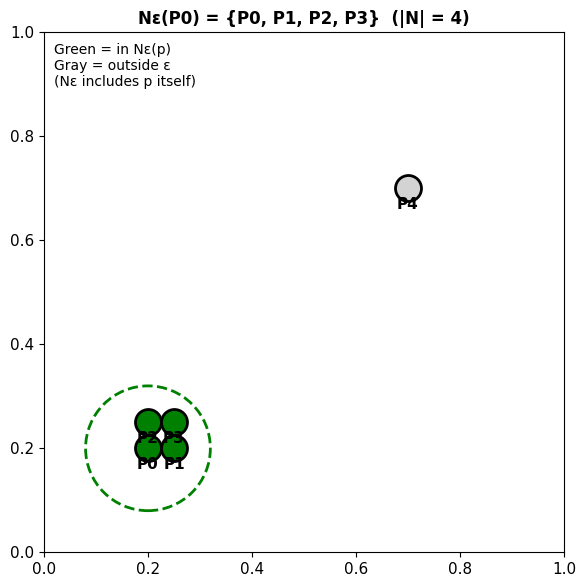

Step 2: Apply localDBSCAN() logic
------------------------------------------------------------
Point |  |Nε(p)| | minPts | Action
------------------------------------------------------------
  P0 |        4 |      2 | core → start cluster + expandCluster()
  P1 |        4 |      2 | core → start cluster + expandCluster()
  P2 |        4 |      2 | core → start cluster + expandCluster()
  P3 |        4 |      2 | core → start cluster + expandCluster()
  P4 |        1 |      2 | noise (clusterId = -1)
------------------------------------------------------------


In [47]:
# --- Neighbor sets Nε(p) INCLUDING the point itself ---
# Use 5 points: P0–P3 close (same cluster), P4 far (alone)
pts_n = [
    {"id": 0, "x": 0.2, "y": 0.2},
    {"id": 1, "x": 0.25, "y": 0.2},
    {"id": 2, "x": 0.2, "y": 0.25},
    {"id": 3, "x": 0.25, "y": 0.25},
    {"id": 4, "x": 0.7, "y": 0.7},
]
eps_n = 0.12  # so P0–P3 within eps of each other, P4 alone
minPts_n = 2
n_n = len(pts_n)

def dist_n(i, j):
    a, b = pts_n[i], pts_n[j]
    return np.sqrt((a["x"] - b["x"]) ** 2 + (a["y"] - b["y"]) ** 2)

# Nε(pi) INCLUDING self (all j with dist(i,j) <= eps)
def N_eps(i):
    return [j for j in range(n_n) if dist_n(i, j) <= eps_n]

neighbor_sets = [N_eps(i) for i in range(n_n)]

# Show only one neighbor set: Nε(P0)
p_idx = 0
n_set = neighbor_sets[p_idx]
fig, ax = plt.subplots(figsize=(7, 6))
for j in range(n_n):
    p = pts_n[j]
    in_N = j in n_set
    color = "green" if in_N else "lightgray"
    ax.scatter(p["x"], p["y"], s=350, c=color, edgecolors="black", linewidth=2, zorder=3)
    ax.text(p["x"], p["y"] - 0.04, "P%d" % j, ha="center", fontsize=11, fontweight="bold")
cx, cy = pts_n[p_idx]["x"], pts_n[p_idx]["y"]
ax.add_patch(Circle((cx, cy), eps_n, fill=False, color="green", linestyle="--", linewidth=2))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
label = "Nε(P%d) = {P%s}  (|N| = %d)" % (p_idx, ", P".join(map(str, n_set)), len(n_set))
ax.set_title(label, fontsize=12, fontweight="bold")
ax.text(0.02, 0.98, "Green = in Nε(p)\nGray = outside ε\n(Nε includes p itself)", transform=ax.transAxes, fontsize=10, va="top")
plt.tight_layout()
plt.show()

# Step 2: localDBSCAN() logic — table
print("Step 2: Apply localDBSCAN() logic")
print("-" * 60)
print("%4s | %8s | %6s | %s" % ("Point", "|Nε(p)|", "minPts", "Action"))
print("-" * 60)
for i in range(n_n):
    k = len(neighbor_sets[i])
    core = k >= minPts_n
    action = "core → start cluster + expandCluster()" if core else "noise (clusterId = -1)"
    print("%4s | %8d | %6d | %s" % ("P%d" % i, k, minPts_n, action))
print("-" * 60)

---
### Expand cluster (inside local DBSCAN)

**Java:** `Utils.localDBSCAN` — the inner **while-loop** that grows a cluster from a core point.

1. **Start** at a core point (has ≥ minPts neighbors within eps).
2. **Seed set** = its neighbors. Assign them to the current cluster.
3. **Expand:** For each point in the seed set that is unvisited, mark visited; if it is core, add *its* neighbors to the seed set and assign them to the cluster.
4. Repeat until the seed set is exhausted → one cluster is complete.

Below: step-by-step visualization of this expansion on a small set of points.

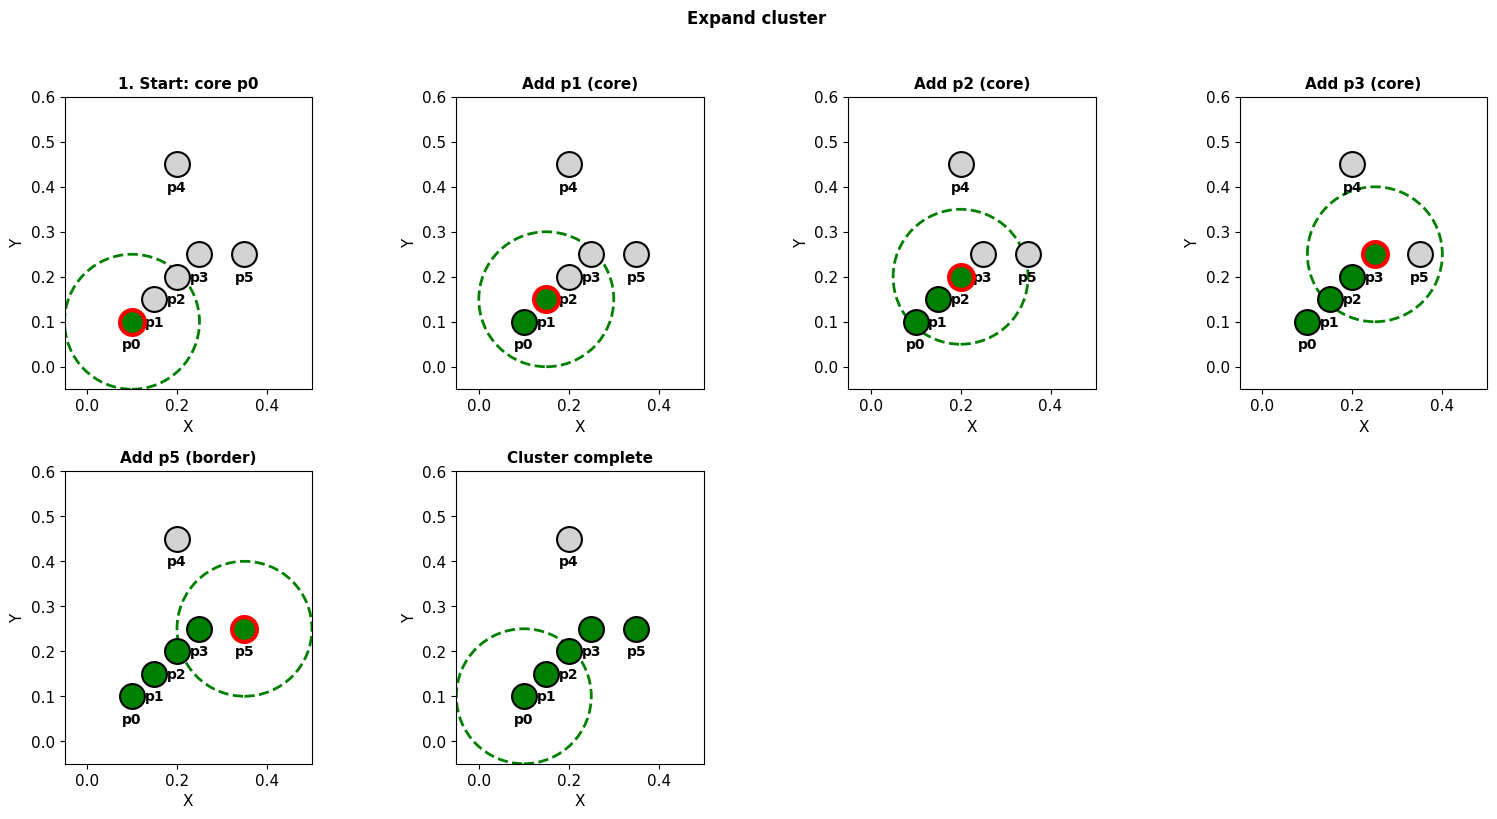

In [44]:
# --- Expand cluster: show ALL cases (every step, core vs border) ---
pts_expand = [p.copy() for p in points[:6]]
n_exp = len(pts_expand)
eps_exp = eps
minPts_exp = minPts

def dist_exp(p, q):
    return np.sqrt((p["x"] - q["x"]) ** 2 + (p["y"] - q["y"]) ** 2)

def get_neighbors_exp(idx):
    return [i for i in range(n_exp) if i != idx and dist_exp(pts_expand[idx], pts_expand[i]) <= eps_exp]

# Record every step: (step_name, cluster_set, current_idx, is_core)
expansion_steps = []
visited_exp = [False] * n_exp
cluster_ids_exp = [0] * n_exp
cluster_id_exp = 1
start_idx = None
for i in range(n_exp):
    if len(get_neighbors_exp(i)) >= minPts_exp:
        start_idx = i
        break
if start_idx is None:
    start_idx = 0
visited_exp[start_idx] = True
cluster_ids_exp[start_idx] = cluster_id_exp
seed_set = list(get_neighbors_exp(start_idx))
expansion_steps.append(("1. Start: core p%d" % start_idx, set([start_idx]), start_idx, True))
j = 0
while j < len(seed_set):
    q = seed_set[j]
    is_core = len(get_neighbors_exp(q)) >= minPts_exp
    if not visited_exp[q]:
        visited_exp[q] = True
        q_neighbors = get_neighbors_exp(q)
        if is_core:
            seed_set.extend(q_neighbors)
    if cluster_ids_exp[q] == 0:
        cluster_ids_exp[q] = cluster_id_exp
        case = "core" if is_core else "border"
        expansion_steps.append(("Add p%d (%s)" % (q, case), set(i for i in range(n_exp) if cluster_ids_exp[i] == cluster_id_exp), q, is_core))
    j += 1
final_cluster = set(i for i in range(n_exp) if cluster_ids_exp[i] == cluster_id_exp)
expansion_steps.append(("Cluster complete", final_cluster, None, None))
# Show all steps (max 8 panels for readability)
plot_steps = expansion_steps[:8]
n_plots = len(plot_steps)
n_cols = min(4, n_plots)
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
if n_plots == 1:
    axes = np.array([[axes]])
elif axes.ndim == 1:
    axes = axes.reshape(1, -1)
for idx, (step_name, cluster_set, current_idx, is_core) in enumerate(plot_steps):
    ax = axes[idx // n_cols, idx % n_cols]
    for i in range(n_exp):
        p = pts_expand[i]
        in_cluster = i in cluster_set
        is_current = i == current_idx
        color = "green" if in_cluster else "lightgray"
        edge = "red" if is_current else "black"
        lw = 3 if is_current else 1.5
        ax.scatter(p["x"], p["y"], s=320, c=color, edgecolors=edge, linewidth=lw, zorder=4 if is_current else 3)
        ax.text(p["x"], p["y"] - 0.06, "p%d" % i, ha="center", fontsize=10, fontweight="bold")
    center_i = current_idx if current_idx is not None else (min(cluster_set) if cluster_set else 0)
    cx, cy = pts_expand[center_i]["x"], pts_expand[center_i]["y"]
    ax.add_patch(Circle((cx, cy), eps_exp, fill=False, color="green", linestyle="--", linewidth=2))
    ax.set_xlim(min(p["x"] for p in pts_expand) - 0.15, max(p["x"] for p in pts_expand) + 0.15)
    ax.set_ylim(min(p["y"] for p in pts_expand) - 0.15, max(p["y"] for p in pts_expand) + 0.15)
    ax.set_aspect("equal")
    ax.set_title(step_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
for idx in range(n_plots, n_rows * n_cols):
    ax = axes[idx // n_cols, idx % n_cols]
    ax.set_visible(False)
fig.suptitle("Expand cluster", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

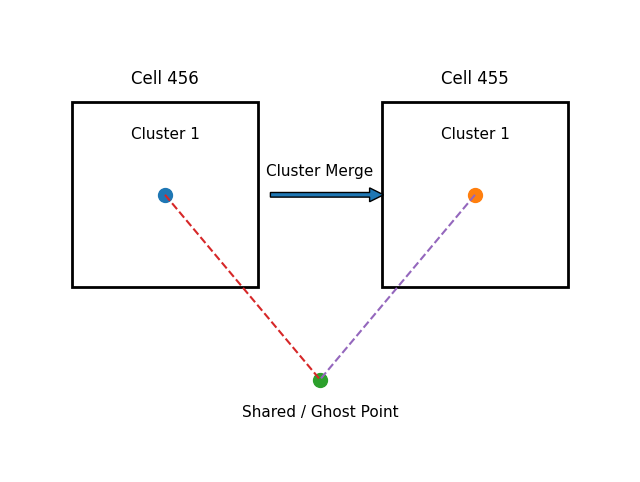

In [51]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrow

fig, ax = plt.subplots(figsize=(8,6))

# ----- Draw Cells -----
cellA = Rectangle((1,5), 3, 2, fill=False, linewidth=2)
cellB = Rectangle((6,5), 3, 2, fill=False, linewidth=2)

ax.add_patch(cellA)
ax.add_patch(cellB)

# Cell Labels
ax.text(2.5,7.2,"Cell 456", ha='center', fontsize=12)
ax.text(7.5,7.2,"Cell 455", ha='center', fontsize=12)

# Cluster Labels
ax.text(2.5,6.6,"Cluster 1", ha='center')
ax.text(7.5,6.6,"Cluster 1", ha='center')

# ----- Points -----
clusterA = (2.5,6)
clusterB = (7.5,6)
sharedPoint = (5,4)

ax.plot(*clusterA, marker='o', markersize=10)
ax.plot(*clusterB, marker='o', markersize=10)
ax.plot(*sharedPoint, marker='o', markersize=10)

# ----- Ghost Connections -----
ax.plot([clusterA[0], sharedPoint[0]],
        [clusterA[1], sharedPoint[1]],
        linestyle='--')

ax.plot([clusterB[0], sharedPoint[0]],
        [clusterB[1], sharedPoint[1]],
        linestyle='--')

# Labels
ax.text(5,3.6,"Shared / Ghost Point", ha='center')

# ----- Logical Merge Arrow -----
arrow = FancyArrow(4.2,6,1.6,0, width=0.05)
ax.add_patch(arrow)
ax.text(5,6.2,"Cluster Merge", ha='center')

# Styling
ax.set_xlim(0,10)
ax.set_ylim(3,8)
ax.axis('off')

plt.show()


---

## Figure 5: Merge Detection (Same Point in Multiple Cells)

**Java Code:** `ExecuteDBSCAN.java` lines 160-196

### Step 1: Group by point ID (`groupedByPoint`)

After local DBSCAN, each point can appear in **multiple cells** (once as home, and as ghost in neighboring cells). We group all such "versions" by point ID:

```java
JavaPairRDD<Long, Iterable<Point>> groupedByPoint =
    dbscanClusteredAsPerCellsRDD.mapToPair(p -> new Tuple2<>(p._2.id, p._2))
                                .groupByKey();
```

So for each point ID we get an **iterable of `Point`** — one per cell it appears in (each with its own `cellId`, `clusterId`, `isCorePoint`).

### Step 2: Emit merge pairs (`samePointMergeRDD`)

For each point, we look at **all pairs** of its versions (from different cells). We emit a merge edge **(keyA, keyB)** when two versions belong to **different** (cell, cluster) IDs and both are valid clusters (and at least one is core):

```java
// key = "cellId_clusterId"
for (i, j) in pairs of indices of pts:
    if a.clusterId <= 0 || b.clusterId <= 0  → skip (noise)
    if !(a.isCorePoint || b.isCorePoint)     → skip (both border)
    keyA = a.cellId + "_" + a.clusterId
    keyB = b.cellId + "_" + b.clusterId
    if keyA != keyB  → merges.add((keyA, keyB))
```

Those **(keyA, keyB)** edges are later used to merge clusters (e.g. via Union-Find or connected components).

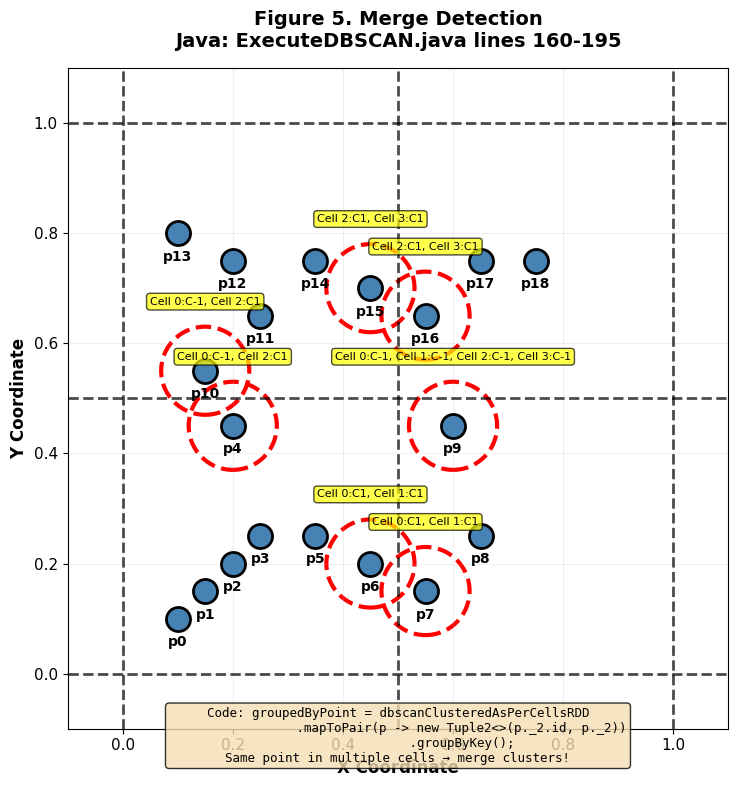

Merge edges: []


In [42]:
fig, ax = plt.subplots(figsize=(8, 8))

# Draw grid
for x_line in x_grid_lines:
    ax.axvline(x_line, color='black', linestyle='--', linewidth=2, alpha=0.7)
for y_line in y_grid_lines:
    ax.axhline(y_line, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Group points by point ID (same point in multiple cells)
point_occurrences = {}
for cell_id, clusters in cell_clusters.items():
    for pid, cid in clusters:
        if pid not in point_occurrences:
            point_occurrences[pid] = []
        point_occurrences[pid].append((cell_id, cid))

# Find merge edges
merge_edges = []
for pid, occurrences in point_occurrences.items():
    if len(occurrences) > 1:  # Point appears in multiple cells
        for i in range(len(occurrences)):
            for j in range(i+1, len(occurrences)):
                cell1, cid1 = occurrences[i]
                cell2, cid2 = occurrences[j]
                if cid1 > 0 and cid2 > 0 and cid1 != cid2:
                    key1 = f"{cell1}_{cid1}"
                    key2 = f"{cell2}_{cid2}"
                    merge_edges.append((key1, key2))

# Plot points
for p in points:
    ax.scatter(p['x'], p['y'], s=300, c='steelblue', 
               edgecolors='black', linewidth=2, zorder=3)
    ax.text(p['x'], p['y']-0.05, f"p{p['id']}", ha='center', fontsize=10, fontweight='bold')

# Highlight points that appear in multiple cells
multi_cell_points = [pid for pid, occs in point_occurrences.items() if len(occs) > 1]
for pid in multi_cell_points:
    p = points[pid]
    circle = Circle((p['x'], p['y']), 0.08, 
                    fill=False, color='red', linewidth=3, linestyle='--')
    ax.add_patch(circle)
    
    # Show which cells this point appears in
    occs = point_occurrences[pid]
    cell_info = ", ".join([f"Cell {c}:C{cl}" for c, cl in occs])
    ax.text(p['x'], p['y']+0.12, cell_info, ha='center', fontsize=8, 
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7))

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_aspect('equal')
ax.set_xlabel('X Coordinate', fontsize=12, fontweight='bold')
ax.set_ylabel('Y Coordinate', fontsize=12, fontweight='bold')
ax.set_title('Figure 5. Merge Detection\nJava: ExecuteDBSCAN.java lines 160-195', 
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.2)

# Code explanation
ax.text(0.5, -0.05,
        "Code: groupedByPoint = dbscanClusteredAsPerCellsRDD\n" +
        "                 .mapToPair(p -> new Tuple2<>(p._2.id, p._2))\n" +
        "                 .groupByKey();\n" +
        "Same point in multiple cells → merge clusters!",
        transform=ax.transAxes,
        fontsize=9,
        ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        family='monospace')

plt.tight_layout()
plt.show()

print(f"Merge edges: {merge_edges}")

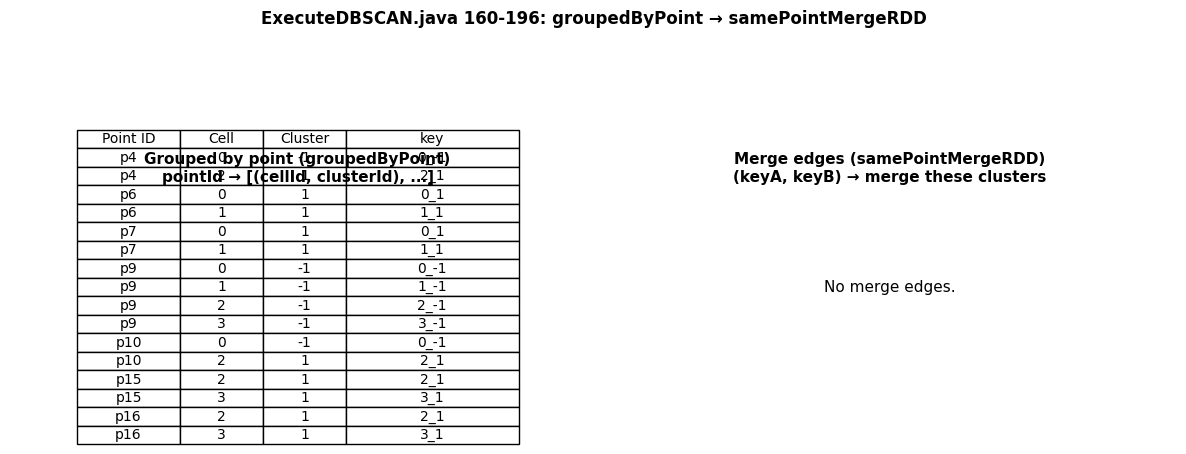

Merge edges (keyA, keyB): []


In [49]:
# --- Visualization: Grouped-by-point table + Merge edges (ExecuteDBSCAN 160-196) ---
# Use point_occurrences and merge_edges from previous cell; recompute if running this cell alone
try:
    _ = point_occurrences
    _ = merge_edges
except NameError:
    point_occurrences = {}
    for cell_id, clusters in cell_clusters.items():
        for pid, cid in clusters:
            if pid not in point_occurrences:
                point_occurrences[pid] = []
            point_occurrences[pid].append((cell_id, cid))
    merge_edges = []
    for pid, occurrences in point_occurrences.items():
        if len(occurrences) > 1:
            for i in range(len(occurrences)):
                for j in range(i+1, len(occurrences)):
                    cell1, cid1 = occurrences[i]
                    cell2, cid2 = occurrences[j]
                    if cid1 > 0 and cid2 > 0 and cid1 != cid2:
                        merge_edges.append((f"{cell1}_{cid1}", f"{cell2}_{cid2}"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Left: Grouped-by-point (same point in multiple cells) ---
ax1.set_title("Grouped by point (groupedByPoint)\npointId → [(cellId, clusterId), ...]", fontsize=11, fontweight="bold")
ax1.axis("off")
multi = [(pid, occs) for pid, occs in point_occurrences.items() if len(occs) > 1]
if not multi:
    ax1.text(0.5, 0.5, "No point appears in multiple cells\nin this run.", ha="center", va="center", fontsize=11)
else:
    table_data = [["Point ID", "Cell", "Cluster", "key"]]
    for pid, occs in sorted(multi, key=lambda x: x[0]):
        for cell_id, cid in occs:
            table_data.append([f"p{pid}", str(cell_id), str(cid), f"{cell_id}_{cid}"])
    table = ax1.table(cellText=table_data, loc="center", cellLoc="center", colWidths=[0.15, 0.12, 0.12, 0.25])
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2.2)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)

# --- Right: Merge edges (samePointMergeRDD) ---
ax2.set_title("Merge edges (samePointMergeRDD)\n(keyA, keyB) → merge these clusters", fontsize=11, fontweight="bold")
ax2.axis("off")
try:
    import networkx as nx
    G = nx.Graph()
    for k1, k2 in merge_edges:
        G.add_edge(k1, k2)
    if G.number_of_nodes() == 0:
        ax2.text(0.5, 0.5, "No merge edges.", ha="center", va="center", fontsize=11)
    else:
        pos = nx.spring_layout(G, seed=42, k=1.5)
        nx.draw_networkx_nodes(G, pos, ax=ax2, node_color="lightblue", node_size=800, edgecolors="black")
        nx.draw_networkx_edges(G, pos, ax=ax2, width=2, alpha=0.7)
        nx.draw_networkx_labels(G, pos, ax=ax2, font_size=9)
        ax2.set_xlim(-1.5, 1.5)
        ax2.set_ylim(-1.5, 1.5)
except Exception as e:
    # Fallback: text list of edges
    if merge_edges:
        text = "\n".join([f"  {a} ↔ {b}" for a, b in merge_edges])
        ax2.text(0.5, 0.5, "Merge edges:\n" + text, ha="center", va="center", fontsize=10, family="monospace")
    else:
        ax2.text(0.5, 0.5, "No merge edges.", ha="center", va="center", fontsize=11)

plt.suptitle("ExecuteDBSCAN.java 160-196: groupedByPoint → samePointMergeRDD", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print("Merge edges (keyA, keyB):", merge_edges)

---

## Figure 6: Global Merging (Union-Find)

**Java Code:** `UnionFindMerge.java` (called from `ExecuteDBSCAN.java`)

Merge edges **(keyA, keyB)** form a graph. **Union-Find** groups keys that are connected into the same **root**; each root gets one **global cluster ID**.

### Steps in `UnionFindMerge.merge()`

1. **Collect** `samePointMergeRDD` to driver → list of `(keyA, keyB)` edges.
2. **Union-Find:** For each edge, `uf.union(e._1, e._2)`. Keys in the same connected component end up with the same **root** (via `uf.find(k)`).
3. **keyToRoot:** For every key that appeared in any edge, `keyToRoot.put(k, uf.find(k))`.
4. **Isolated clusters:** From `clusteredRDD`, collect all distinct `cellId_clusterId` for points with `clusterId > 0`. For any key not yet in `keyToRoot`, add `keyToRoot.putIfAbsent(s, s)` (root = self).
5. **rootToGlobal:** Assign global ID 1, 2, 3, … to each distinct root.
6. **edgesToGlobal:** Final map `key → globalId` = `rootToGlobal.get(keyToRoot.get(key))`. This is returned and used to relabel clusters.

SyntaxError: keyword argument repeated: s (2267443047.py, line 52)

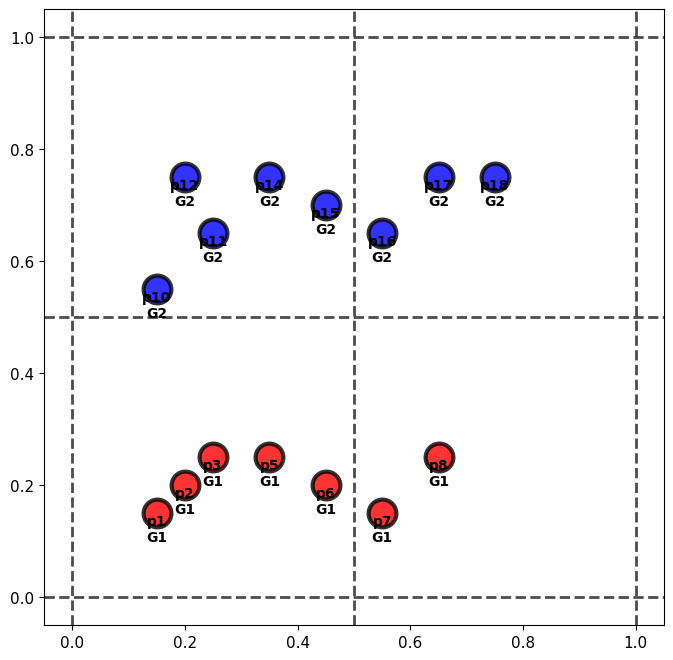

In [16]:
import networkx as nx

fig, ax = plt.subplots(figsize=(8, 8))

# Build merge graph
G = nx.Graph()
for key1, key2 in merge_edges:
    G.add_edge(key1, key2)

# Find connected components
components = list(nx.connected_components(G))

# Map cluster keys to final global cluster IDs
global_cluster_map = {}
for global_id, component in enumerate(components, start=1):
    for key in component:
        global_cluster_map[key] = global_id

# Draw grid
for x_line in x_grid_lines:
    ax.axvline(x_line, color='black', linestyle='--', linewidth=2, alpha=0.7)
for y_line in y_grid_lines:
    ax.axhline(y_line, color='black', linestyle='--', linewidth=2, alpha=0.7)

# Assign final global clusters to home points
final_clusters = {}
for cell_id, clusters in cell_clusters.items():
    for pid, local_cid in clusters:
        p = points[pid]
        home_cell = get_home_cell(p['x'], p['y'])
        
        # Only assign to home points
        if home_cell == cell_id and local_cid > 0:
            key = f"{cell_id}_{local_cid}"
            global_cid = global_cluster_map.get(key, local_cid)
            final_clusters[pid] = global_cid

# Plot points with final global clusters
global_colors = {1: 'red', 2: 'blue', 3: 'green', 4: 'orange'}
for pid, global_cid in final_clusters.items():
    p = points[pid]
    color = global_colors.get(global_cid, 'gray')
    ax.scatter(p['x'], p['y'], s=400, c=color, 
               edgecolors='black', linewidth=3, zorder=3, alpha=0.8)
    ax.text(p['x'], p['y']-0.05, f"p{pid}\nG{global_cid}", 
            ha='center', fontsize=10, fontweight='bold')

# Plot noise points
for pid, p in enumerate(points):
    if pid not in final_clusters:
        ax.scatter(p['x'], p['y'], s=300, c='gray', 
                   edgecolors='black', linewidth=2, zorder=3, marker='x', s=400)
        ax.text(p['x'], p['y']-0.05, f"p{pid}\nN", 
                ha='center', fontsize=10, fontweight='bold')

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.set_aspect('equal')
ax.set_xlabel('X Coordinate', fontsize=12, fontweight='bold')
ax.set_ylabel('Y Coordinate', fontsize=12, fontweight='bold')
ax.set_title('Figure 6. Global Merging (Connected Components)\nJava: UnionFindMerge.java',
             fontsize=14, fontweight='bold', pad=15)
ax.grid(True, alpha=0.2)

# Code explanation
ax.text(0.5, -0.05,
        "Code: UnionFindMerge.java — Union-Find on merge edges\n" +
        "       Same cluster fragments → merged into global cluster\n" +
        "       Final clusters assigned to home points only",
        transform=ax.transAxes,
        fontsize=9,
        ha='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8),
        family='monospace')

plt.tight_layout()
plt.show()

print(f"Final global clusters: {final_clusters}")

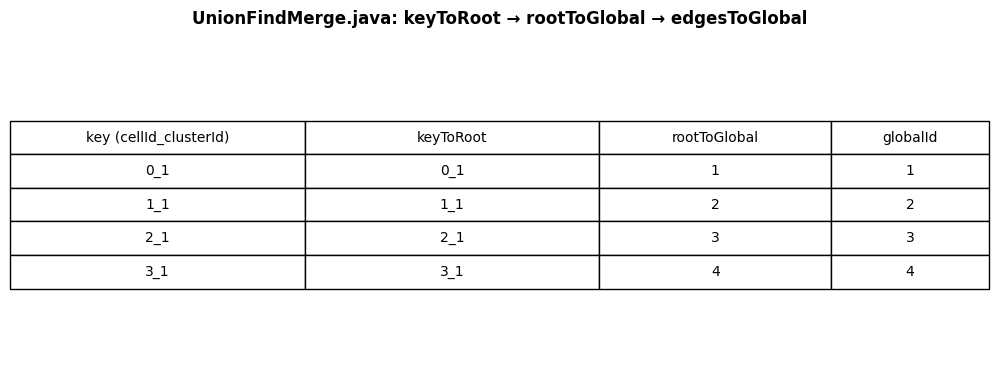

edgesToGlobal (key → globalId): {'1_1': 2, '3_1': 4, '2_1': 3, '0_1': 1}


In [52]:
# --- UnionFindMerge.java logic in Python (keyToRoot → rootToGlobal → edgesToGlobal) ---
class UnionFindString:
    def __init__(self):
        self.parent = {}
    def find(self, x):
        self.parent.setdefault(x, x)
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    def union(self, a, b):
        pa, pb = self.find(a), self.find(b)
        if pa != pb:
            self.parent[pa] = pb

# 1) Union all merge edges
try:
    _ = merge_edges
except NameError:
    merge_edges = []
    point_occurrences = {}
    for cell_id, clusters in cell_clusters.items():
        for pid, cid in clusters:
            point_occurrences.setdefault(pid, []).append((cell_id, cid))
    for pid, occs in point_occurrences.items():
        if len(occs) <= 1:
            continue
        for i in range(len(occs)):
            for j in range(i+1, len(occs)):
                c1, id1 = occs[i]
                c2, id2 = occs[j]
                if id1 > 0 and id2 > 0 and (c1 != c2 or id1 != id2):
                    merge_edges.append((f"{c1}_{id1}", f"{c2}_{id2}"))

uf = UnionFindString()
for (k1, k2) in merge_edges:
    uf.union(k1, k2)

# 2) keyToRoot
key_to_root = {k: uf.find(k) for k in uf.parent}

# 3) Isolated clusters (all keys from cell_clusters with clusterId > 0)
all_keys = set()
for cell_id, clusters in cell_clusters.items():
    for pid, cid in clusters:
        if cid > 0:
            all_keys.add(f"{cell_id}_{cid}")
for s in all_keys:
    key_to_root.setdefault(s, s)

# 4) rootToGlobal
roots = sorted(set(key_to_root.values()))
root_to_global = {r: g for g, r in enumerate(roots, start=1)}

# 5) edgesToGlobal (final key → globalId)
edges_to_global = {k: root_to_global[key_to_root[k]] for k in key_to_root}

# Visualize
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis("off")
ax.set_title("UnionFindMerge.java: keyToRoot → rootToGlobal → edgesToGlobal", fontsize=12, fontweight="bold")
table_data = [["key (cellId_clusterId)", "keyToRoot", "rootToGlobal", "globalId"]]
for k in sorted(edges_to_global.keys(), key=lambda x: (x,)):
    root = key_to_root[k]
    gid = edges_to_global[k]
    table_data.append([k, root, str(root_to_global.get(root, "-")), str(gid)])
t = ax.table(cellText=table_data, loc="center", cellLoc="center", colWidths=[0.28, 0.28, 0.22, 0.15])
t.auto_set_font_size(False)
t.set_fontsize(10)
t.scale(1.2, 1.8)
plt.tight_layout()
plt.show()
print("edgesToGlobal (key → globalId):", edges_to_global)

/var/folders/0c/bg7lszj94cz0b84y_45p31x80000gn/T/ipykernel_7620/2977497629.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 10)


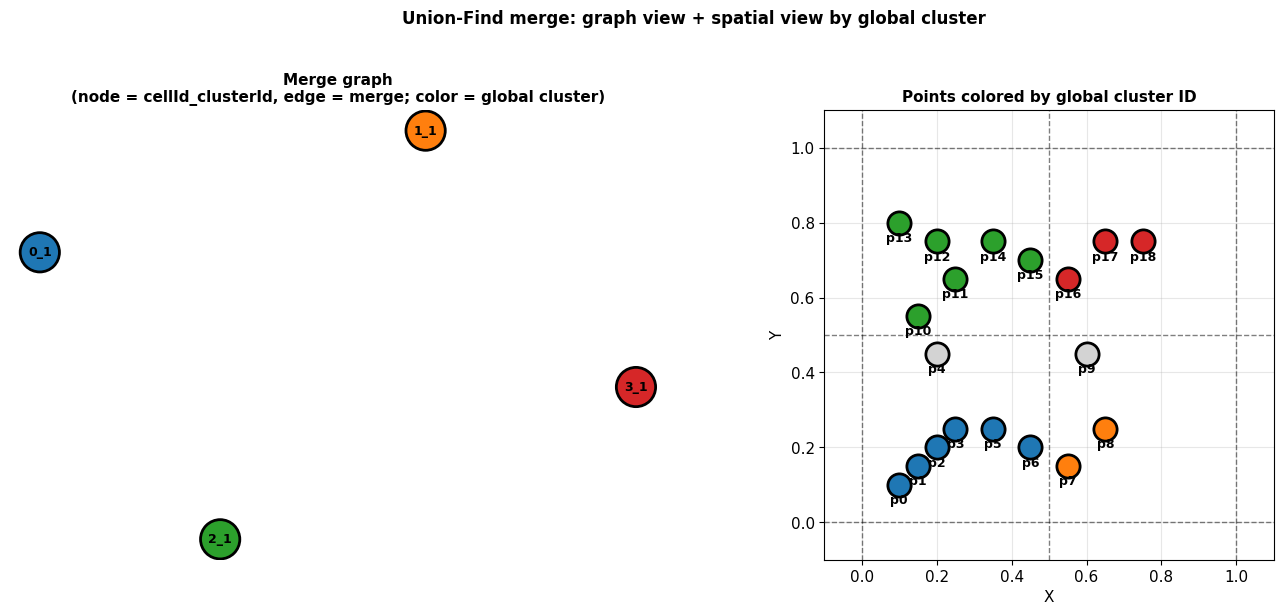

In [54]:
# --- Visualization: Merge graph (nodes = keys, edges = merge) colored by global cluster ---
import networkx as nx

# Use edges_to_global, key_to_root, merge_edges from previous cell (or minimal defaults)
try:
    _ = edges_to_global
    _ = key_to_root
except NameError:
    edges_to_global = {}
    key_to_root = {}
try:
    _ = merge_edges
except NameError:
    merge_edges = []

cmap = plt.cm.get_cmap("tab10", 10)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# --- Panel 1: Merge graph — nodes colored by global cluster ID ---
G = nx.Graph()
all_keys = set(key_to_root.keys()) if key_to_root else set(edges_to_global.keys()) if edges_to_global else set()
for k1, k2 in merge_edges:
    all_keys.add(k1)
    all_keys.add(k2)
for k in all_keys:
    G.add_node(k)
for (k1, k2) in merge_edges:
    G.add_edge(k1, k2)

if G.number_of_nodes() > 0:
    pos = nx.spring_layout(G, seed=42, k=1.2)
    global_ids = [edges_to_global.get(n, 0) for n in G.nodes()]
    n_global = max(global_ids) if global_ids else 1
    colors = [cmap((g - 1) % 10) if g > 0 else "lightgray" for g in global_ids]
    nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=colors, node_size=800, edgecolors="black", linewidths=2)
    nx.draw_networkx_edges(G, pos, ax=ax1, width=2, alpha=0.7)
    nx.draw_networkx_labels(G, pos, ax=ax1, font_size=9, font_weight="bold")
    ax1.set_title("Merge graph\n(node = cellId_clusterId, edge = merge; color = global cluster)", fontsize=11, fontweight="bold")
else:
    ax1.text(0.5, 0.5, "No merge graph\n(run previous cells first)", ha="center", va="center", fontsize=12)
ax1.axis("off")

# --- Panel 2: Spatial view — points colored by global cluster ID ---
ax2.set_title("Points colored by global cluster ID", fontsize=11, fontweight="bold")
get_home = get_home_cell_fig4 if "get_home_cell_fig4" in dir() else (get_home_cell if "get_home_cell" in dir() else None)
try:
    for p in points:
        pid = p["id"]
        home_cell = get_home(p["x"], p["y"]) if get_home else 0
        key = None
        for cell_id, clusters in cell_clusters.items():
            for pidx, cid in clusters:
                if pidx == pid and cell_id == home_cell and cid > 0:
                    key = f"{cell_id}_{cid}"
                    break
            if key:
                break
        gid = edges_to_global.get(key, -1) if key else -1
        color = cmap((gid - 1) % 10) if gid > 0 else "lightgray"
        ax2.scatter(p["x"], p["y"], s=280, c=[color], edgecolors="black", linewidths=2, zorder=3)
        ax2.text(p["x"], p["y"] - 0.05, f"p{pid}", ha="center", fontsize=9, fontweight="bold")
    for x_line in x_grid_lines:
        ax2.axvline(x_line, color="black", linestyle="--", linewidth=1, alpha=0.5)
    for y_line in y_grid_lines:
        ax2.axhline(y_line, color="black", linestyle="--", linewidth=1, alpha=0.5)
    ax2.set_xlim(-0.1, 1.1)
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_aspect("equal")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
except Exception as e:
    ax2.text(0.5, 0.5, "Run previous cells for spatial view.", ha="center", va="center", fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle("Union-Find merge: graph view + spatial view by global cluster", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# UnionFind Merge 

---

## Summary: Distributed DBSCAN Architecture

**Key Steps:**
1. **Grid Partitioning** - Divide space into cells
2. **Home Cell Assignment** - Assign each point to its home cell
3. **Ghost Point Replication** - Replicate boundary points to neighbors
4. **Local DBSCAN** - Run DBSCAN independently in each cell
5. **Merge Detection** - Identify clusters that should be merged
6. **Global Merging** - Use Union-Find/GraphX to merge connected clusters

**Why Distributed?**
- Each cell processes independently → **parallel execution**
- Ghost points ensure **correctness** for boundary clusters
- Merge step combines local results into **global clusters**

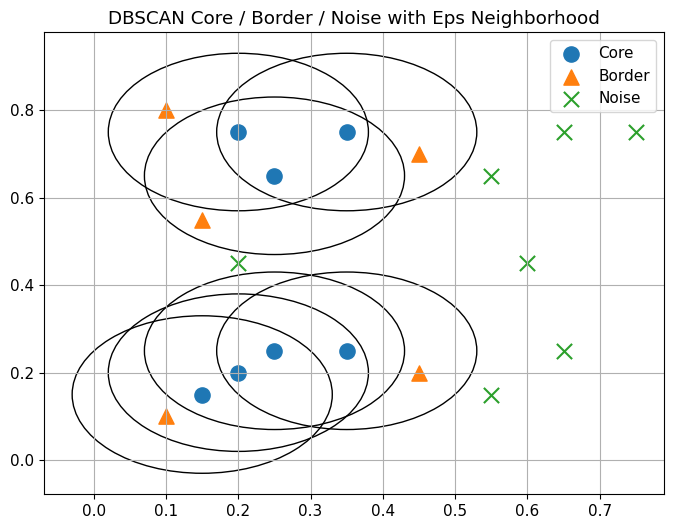

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from matplotlib.patches import Circle

# -------------------------------
# Data
# -------------------------------
points = np.array([
    (0.10,0.10),(0.15,0.15),(0.20,0.20),(0.25,0.25),(0.20,0.45),
    (0.35,0.25),(0.45,0.20),(0.55,0.15),(0.65,0.25),(0.60,0.45),
    (0.15,0.55),(0.25,0.65),(0.20,0.75),(0.10,0.80),
    (0.35,0.75),(0.45,0.70),(0.55,0.65),(0.65,0.75),(0.75,0.75)
])

# -------------------------------
# DBSCAN Parameters
# -------------------------------
eps = 0.18
min_pts = 4

# -------------------------------
# Neighbor Search
# -------------------------------
nbrs = NearestNeighbors(radius=eps).fit(points)
neighbors = nbrs.radius_neighbors(points, return_distance=False)

# -------------------------------
# Classification
# -------------------------------
core_mask = np.array([len(n) >= min_pts for n in neighbors])

core_points = []
border_points = []
noise_points = []

for i in range(len(points)):
    
    if core_mask[i]:
        core_points.append(points[i])
        
    else:
        is_border = any(core_mask[j] for j in neighbors[i])
        
        if is_border:
            border_points.append(points[i])
        else:
            noise_points.append(points[i])

core_points = np.array(core_points)
border_points = np.array(border_points)
noise_points = np.array(noise_points)

# -------------------------------
# Plot
# -------------------------------
fig, ax = plt.subplots(figsize=(8,6))

# Plot points
if len(core_points) > 0:
    ax.scatter(core_points[:,0], core_points[:,1], s=120, label='Core')

if len(border_points) > 0:
    ax.scatter(border_points[:,0], border_points[:,1], s=120, marker='^', label='Border')

if len(noise_points) > 0:
    ax.scatter(noise_points[:,0], noise_points[:,1], s=120, marker='x', label='Noise')

# -------------------------------
# Draw Eps Circle around Core Points
# -------------------------------
for p in core_points:
    circle = Circle(p, eps, fill=False)
    ax.add_patch(circle)

ax.set_title("DBSCAN Core / Border / Noise with Eps Neighborhood")
ax.legend()
ax.grid(True)
plt.show()


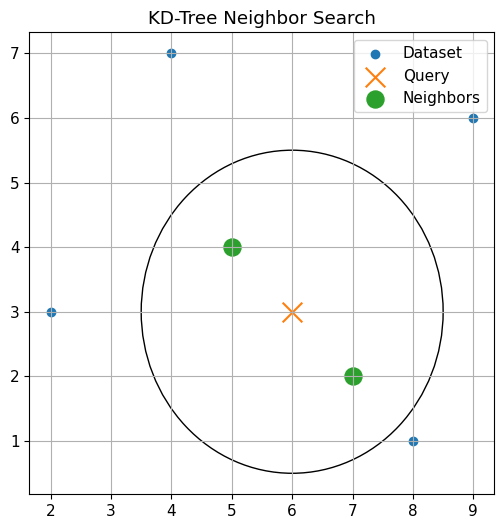

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# -----------------------
# Dataset
# -----------------------
points = np.array([
    [2,3],
    [5,4],
    [9,6],
    [4,7],
    [8,1],
    [7,2]
])

# Query point
query = np.array([6,3])

# Radius
radius = 2.5

# -----------------------
# Build KD-Tree
# -----------------------
tree = KDTree(points)

# Search neighbors inside radius
neighbors = tree.query_ball_point(query, radius)

neighbor_points = points[neighbors]

# -----------------------
# Visualization
# -----------------------
plt.figure(figsize=(6,6))

# Plot all points
plt.scatter(points[:,0], points[:,1], label="Dataset")

# Plot query point
plt.scatter(query[0], query[1], s=200, marker='x', label="Query")

# Plot neighbors
if len(neighbor_points) > 0:
    plt.scatter(neighbor_points[:,0], neighbor_points[:,1], 
                s=150, label="Neighbors")

# Draw search circle
circle = plt.Circle(query, radius, fill=False)
plt.gca().add_patch(circle)

plt.legend()
plt.grid(True)
plt.title("KD-Tree Neighbor Search")
plt.show()
